### LSE Business Analytics for Executives

# Course 2: Data Analytics using Python

## Assignment: Data Analysis using Python

You'll be working with real-world data to address a problem faced by the National Health Service (NHS). The analysis will require you to utilise Python to explore the available data, create visualisations to identify trends, and extract meaningful insights to inform decision-making.

## Introduction

This analysis addresses the NHS business problem of missed GP appointments by using Python to explore four datasets and gauge capacity and resource utilisation.

**The two key business questions are:**
1. Has there been adequate staff and capacity in the networks?
2. What was the actual utilisation of resources?

**Datasets used:**
- **AD – actual_duration.csv**: Regional info, appointment date, duration, and count of appointments (Dec 2021–Jun 2022)
- **AR – appointments_regional.csv**: Monthly data by status, HCP type, mode, and booking time (Jan 2020–Jun 2022)
- **NC – national_categories.xlsx**: Daily data by service setting, context type, and national category (Aug 2021–Jun 2022)
- **Tweets.csv**: Twitter/X data with healthcare-related hashtags

#

# Assignment Activity 1

### Plan your approach

**Analytical Plan – NHS Diagnostic Analysis**

**Business Problem:** The NHS faces a significant and growing challenge with missed GP appointments — known as DNA (Did Not Attend) events. Understanding the scale of this problem requires analysing appointment capacity, utilisation, and attendance patterns to identify where and when the system is most at risk.

**Two core questions posed by NHS:**
1. Has there been adequate staff and capacity in the networks?
2. What was the actual utilisation of resources?

**Key Assumption:** The NHS can accommodate a maximum of **1,200,000 appointments per day** (36,000,000 per month). This will serve as the capacity benchmark throughout the analysis.

**Analytical Steps:**
1. **Import & sense-check** all datasets (missing values, dtypes, descriptive stats, duplicates)
2. **Explore** preliminary questions: locations, categories, date ranges, top service settings
3. **Visualise monthly & seasonal trends** across service settings, context types, and national categories
4. **Analyse Twitter/X data** to identify top trending healthcare hashtags
5. **Investigate capacity utilisation**, HCP type trends, attendance, appointment mode, and booking lead times
6. **Summarise findings and provide recommendations** to the NHS

**Data Quality Note:** Per the metadata file, data is collected from GP systems not designed for analysis, and there is widespread variation in data entry between practices. Limitations will be noted where relevant. The NHS also notes that this data does not provide a complete view of GP activity and should not be used to directly infer workload.

#

# Assignment Activity 2

### Prepare your workstation

In [1]:
# Import the necessary libraries.
import pandas as pd
import numpy as np

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

#### Actual Duration (ad)

In [2]:
# Import and sense-check the actual_duration.csv data set as ad.
ad = pd.read_csv('actual_duration.csv')

# View the DataFrame.
display(ad)

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730
...,...,...,...,...,...,...,...,...
137788,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,31-60 Minutes,430
137789,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,21-30 Minutes,751
137790,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,16-20 Minutes,921
137791,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,11-15 Minutes,1439


In [3]:
# Determine whether there are missing values.
print("Missing values per column:")
print(ad.isnull().sum())
print(f"\nTotal rows with any missing value: {ad.isnull().any(axis=1).sum()}")

Missing values per column:
sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64

Total rows with any missing value: 0


In [4]:
# Determine the metadata of the data set.
print(ad.dtypes)
print()
ad.info()

sub_icb_location_code        object
sub_icb_location_ons_code    object
sub_icb_location_name        object
icb_ons_code                 object
region_ons_code              object
appointment_date             object
actual_duration              object
count_of_appointments         int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)

In [5]:
# Determine the descriptive statistics of the data set.
print(ad.describe())

       count_of_appointments
count          137793.000000
mean             1219.080011
std              1546.902956
min                 1.000000
25%               194.000000
50%               696.000000
75%              1621.000000
max             15400.000000


**Observations on AD:**
The actual_duration DataFrame has **137,793 rows and 8 columns** with **no missing values**. The only numeric column is `count_of_appointments` (int64); all others are object type. Duration categories range from '1-5 Minutes' to '31-60 Minutes', with an 'Unknown / Data Quality' category for unreliable entries. The dataset covers **December 2021 to June 2022** — the shortest date range of the three datasets. The mean count of appointments per row is ~1,219, with a maximum of 15,400.

#### Appointments Regional (ar)

In [6]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv('appointments_regional.csv')

# View the DataFrame.
display(ar)

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971
...,...,...,...,...,...,...,...
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17


In [7]:
# Determine whether there are missing values.
print("Missing values per column:")
print(ar.isnull().sum())
print(f"\nTotal rows with any missing value: {ar.isnull().any(axis=1).sum()}")

Missing values per column:
icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64

Total rows with any missing value: 0


In [8]:
# Determine the metadata of the data set.
print(ar.dtypes)

icb_ons_code                         object
appointment_month                    object
appointment_status                   object
hcp_type                             object
appointment_mode                     object
time_between_book_and_appointment    object
count_of_appointments                 int64
dtype: object


In [9]:
# Determine the descriptive statistics of the data set.
ar.describe()

,count_of_appointments
count,596821.000000
mean,1244.601857
std,5856.887042
min,1.000000
25%,7.000000
50%,47.000000
75%,308.000000
max,211265.000000


**Observations on AR:**
The appointments_regional DataFrame has **596,821 rows and 7 columns** with **no missing values**. It has the widest date range, covering **January 2020 to June 2022**. Key variables include `appointment_status` (Attended/DNA/Unknown), `hcp_type` (GP/Other Practice Staff/Unknown), `appointment_mode` (Face-to-Face/Telephone/Home Visit/Video/Unknown), and `time_between_book_and_appointment`. The `appointment_month` is stored as 'YYYY-MM' string format and will need conversion to datetime for time-series analysis.

#### National Categories (nc)

In [10]:
# Import and sense-check the national_categories.xlsx data set as nc.
nc = pd.read_excel('national_categories.xlsx')

# View the DataFrame.
display(nc)

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08
...,...,...,...,...,...,...,...,...
817389,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06
817390,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06
817391,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06
817392,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06


In [11]:
# Determine whether there are missing values.
print("Missing values per column:")
print(nc.isnull().sum())
print(f"\nTotal rows with any missing value: {nc.isnull().any(axis=1).sum()}")

Missing values per column:
appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64

Total rows with any missing value: 0


In [12]:
# Determine the metadata of the data set.
print(nc.dtypes)

appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month                object
dtype: object


In [13]:
# Determine the descriptive statistics of the data set.
nc.describe(include='all')

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
count,817394,817394,817394,817394,817394,817394,817394.000000,817394
unique,NaN,42,106,5,3,18,NaN,11
top,NaN,E54000057,NHS North West London ICB - W2U3Z,General Practice,Care Related Encounter,Inconsistent Mapping,NaN,2022-03
freq,NaN,59180,13007,359274,700481,89494,NaN,82822
mean,2022-01-16 00:50:35.860796160,NaN,NaN,NaN,NaN,NaN,362.183684,NaN
min,2021-08-01 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
25%,2021-10-25 00:00:00,NaN,NaN,NaN,NaN,NaN,7.000000,NaN
50%,2022-01-18 00:00:00,NaN,NaN,NaN,NaN,NaN,25.000000,NaN
75%,2022-04-07 00:00:00,NaN,NaN,NaN,NaN,NaN,128.000000,NaN
max,2022-06-30 00:00:00,NaN,NaN,NaN,NaN,NaN,16590.000000,NaN


**Observations on NC:**
The national_categories DataFrame has **817,394 rows and 8 columns** with **no missing values**. It covers **August 2021 to June 2022** and is the most detailed dataset for categorical analysis. After importing from xlsx, `appointment_date` is already in datetime64 format. The `appointment_month` column is stored as object/string in 'YYYY-MM' format. This dataset is the primary source for service setting, context type, and national category analysis throughout Activities 3 and 4.

### Explore the data set

**Question 1:** How many locations are there in the data set?

In [14]:
# Determine the number of locations.
num_locations = nc['sub_icb_location_name'].nunique()
print(f"Number of unique locations in the data set: {num_locations}")

Number of unique locations in the data set: 106


**Answer:** There are **106 unique Sub-ICB locations** in the dataset, representing general practices across England at the sub-Integrated Care Board level.

**Question 2:** What are the five locations with the highest number of appointments?

In [15]:
# Determine the top five locations based on record count.
top5 = nc.groupby('sub_icb_location_name')['sub_icb_location_name'].count()
print("Top 5 locations by number of records:")
print(top5.sort_values(ascending=False).head(5))

Top 5 locations by number of records:
sub_icb_location_name
NHS North West London ICB - W2U3Z              13007
NHS Kent and Medway ICB - 91Q                  12637
NHS Devon ICB - 15N                            12526
NHS Hampshire and Isle Of Wight ICB - D9Y0V    12171
NHS North East London ICB - A3A8R              11837
Name: sub_icb_location_name, dtype: int64


**Answer:** The five locations with the highest number of records are:
1. NHS North West London ICB - W2U3Z — 13,007
2. NHS Kent and Medway ICB - 91Q — 12,637
3. NHS Devon ICB - 15N — 12,526
4. NHS Hampshire and Isle Of Wight ICB - D9Y0V — 12,171
5. NHS North East London ICB - A3A8R — 11,837

All five top locations are in the **South of England**, reflecting the higher population density. NHS North West London has the most records — this location will be used for specific location-based analysis in Activity 3.

**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [16]:
# Determine the number of service settings.
print(f"Number of service settings: {nc['service_setting'].nunique()}")
print(nc['service_setting'].unique())

Number of service settings: 5
['Primary Care Network' 'Other' 'General Practice' 'Unmapped'
 'Extended Access Provision']


In [17]:
# Determine the number of context types.
print(f"Number of context types: {nc['context_type'].nunique()}")
print(nc['context_type'].unique())

Number of context types: 3
['Care Related Encounter' 'Unmapped' 'Inconsistent Mapping']


In [18]:
# Determine the number of national categories.
print(f"Number of national categories: {nc['national_category'].nunique()}")
print(nc['national_category'].unique())

Number of national categories: 18
['Patient contact during Care Home Round' 'Planned Clinics' 'Home Visit'
 'General Consultation Acute' 'Structured Medication Review'
 'Care Home Visit' 'Unmapped' 'Clinical Triage'
 'Planned Clinical Procedure' 'Inconsistent Mapping'
 'Care Home Needs Assessment & Personalised Care and Support Planning'
 'General Consultation Routine'
 'Service provided by organisation external to the practice'
 'Unplanned Clinical Activity' 'Social Prescribing Service'
 'Non-contractual chargeable work'
 'Group Consultation and Group Education' 'Walk-in']


In [19]:
# Determine the number of appointment statuses.
# Note: appointment_status is in the ar DataFrame.
print(f"Number of appointment statuses: {ar['appointment_status'].nunique()}")
print(ar['appointment_status'].unique())

Number of appointment statuses: 3
['Attended' 'DNA' 'Unknown']


**Answer:**

| Category | Count | Most Common |
|----------|-------|-------------|
| Service Settings | 5 | General Practice |
| Context Types | 3 | Care Related Encounter |
| National Categories | 18 | General Consultation Routine |
| Appointment Statuses | 3 | Attended |

General Practice accounts for ≈91.5% of appointments and Care Related Encounter for ≈86.8%, reflecting the NHS's primary care-focused delivery model.

#

# Assignment Activity 3

### Continue to explore the data and search for answers to more specific questions posed by the NHS.

**Question 1:** Between what dates were appointments scheduled?

In [20]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.
print("AD - appointment_date format:")
print(ad['appointment_date'].head())
print(f"dtype: {ad['appointment_date'].dtype}")

AD - appointment_date format:
0    01-Dec-21
1    01-Dec-21
2    01-Dec-21
3    01-Dec-21
4    01-Dec-21
Name: appointment_date, dtype: object
dtype: object


In [21]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.
print("NC - appointment_date format:")
print(nc['appointment_date'].head())
print(f"dtype: {nc['appointment_date'].dtype}")

NC - appointment_date format:
0   2021-08-02
1   2021-08-02
2   2021-08-02
3   2021-08-02
4   2021-08-02
Name: appointment_date, dtype: datetime64[ns]
dtype: datetime64[ns]


In [22]:
# Change the date format of ad['appointment_date'].
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'], format='%d-%b-%y')

# View the DataFrame.
print("AD after conversion:")
print(ad['appointment_date'].head())
print(f"dtype: {ad['appointment_date'].dtype}")

AD after conversion:
0   2021-12-01
1   2021-12-01
2   2021-12-01
3   2021-12-01
4   2021-12-01
Name: appointment_date, dtype: datetime64[ns]
dtype: datetime64[ns]


In [23]:
# Change the date format of ar['appointment_month'].
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'])

# View the DataFrame.
print("AR after conversion:")
print(ar['appointment_month'].head())
print(f"dtype: {ar['appointment_month'].dtype}")

AR after conversion:
0   2020-01-01
1   2020-01-01
2   2020-01-01
3   2020-01-01
4   2020-01-01
Name: appointment_month, dtype: datetime64[ns]
dtype: datetime64[ns]


In [24]:
# Determine the minimum and maximum dates in the ad DataFrame.
print(f"AD - Earliest appointment date : {ad['appointment_date'].min().strftime('%Y-%m-%d')}")
print(f"AD - Latest appointment date   : {ad['appointment_date'].max().strftime('%Y-%m-%d')}")

AD - Earliest appointment date : 2021-12-01
AD - Latest appointment date   : 2022-06-30


In [25]:
# Determine the minimum and maximum dates in the nc DataFrame.
print(f"NC - Earliest appointment date : {nc['appointment_date'].min().strftime('%Y-%m-%d')}")
print(f"NC - Latest appointment date   : {nc['appointment_date'].max().strftime('%Y-%m-%d')}")

NC - Earliest appointment date : 2021-08-01
NC - Latest appointment date   : 2022-06-30


**Answer – Date Ranges:**

| Dataset | Earliest Date | Latest Date |
|---------|--------------|-------------|
| AD – Actual Duration | 2021-12-01 | 2022-06-30 |
| AR – Appointments Regional | 2020-01-01 | 2022-06-01 |
| NC – National Categories | 2021-08-01 | 2022-06-30 |

The **overlapping period** across all three datasets is **2021-12-01 to 2022-06-30**. The NC dataset (Aug 2021–Jun 2022) provides the best coverage for categorical analysis. The AR dataset's longer range (from Jan 2020) is useful for observing longer-term trends including pre- and post-COVID patterns in Activity 6.

**Question 2:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [26]:
# For each of these service settings, determine the number of records available for the period and the location.
nc_subset = nc[
    (nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z') &
    (nc['appointment_date'] >= '2022-01-01') &
    (nc['appointment_date'] <= '2022-06-01')
]

nw_london_ss = nc_subset.groupby('service_setting')['count_of_appointments'].sum()

# View the output.
print("Service settings – NHS North West London (Jan–Jun 2022):")
print(nw_london_ss.sort_values(ascending=False))

Service settings – NHS North West London (Jan–Jun 2022):
service_setting
General Practice             4804239
Unmapped                      391106
Other                         152897
Primary Care Network          109840
Extended Access Provision      98159
Name: count_of_appointments, dtype: int64


**Answer:** **General Practice** was the most popular service setting for NHS North West London between 1 January and 1 June 2022 by a substantial margin, consistent with the national picture. This confirms that the overwhelming majority of primary care appointments in this high-volume location are delivered through General Practice.

**Question 3:** Which month had the highest number of appointments?

In [27]:
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() and sort_values() functions.
appts_per_month = nc.groupby('appointment_month')['count_of_appointments'].sum()
appts_per_month = appts_per_month.sort_values(ascending=False)

print("Total appointments per month (sorted highest to lowest):")
print(appts_per_month)
print(f"\nBusiest month: {appts_per_month.index[0]} with {appts_per_month.iloc[0]:,} appointments")

Total appointments per month (sorted highest to lowest):
appointment_month
2021-11    30405070
2021-10    30303834
2022-03    29595038
2021-09    28522501
2022-05    27495508
2022-06    25828078
2022-01    25635474
2022-02    25355260
2021-12    25140776
2022-04    23913060
2021-08    23852171
Name: count_of_appointments, dtype: int64

Busiest month: 2021-11 with 30,405,070 appointments


**Answer:** **November 2021** had the highest number of appointments (30,405,070), followed closely by October 2021 (30,303,834). This autumn peak is consistent with seasonal increases in demand driven by winter illnesses such as flu and respiratory infections.

**Question 4:** What was the total number of records per month?

In [28]:
# Total number of records per month (count of rows, not sum of appointments).
records_per_month = nc.groupby('appointment_month').size().reset_index(name='number_of_records')
records_per_month = records_per_month.sort_values('appointment_month')

print("Total number of records per month (NC dataset):")
print(records_per_month.to_string(index=False))
print(f"\nAverage records per month: {records_per_month['number_of_records'].mean():,.0f}")

Total number of records per month (NC dataset):
appointment_month  number_of_records
          2021-08              69999
          2021-09              74922
          2021-10              74078
          2021-11              77652
          2021-12              72651
          2022-01              71896
          2022-02              71769
          2022-03              82822
          2022-04              70012
          2022-05              77425
          2022-06              74168

Average records per month: 74,309


**Answer:** Records per month range from ≈69,999 (August 2021) to ≈82,822 (March 2022), averaging ≈74,309 per month. 

**Important distinction:** Each 'record' (row) represents a specific combination of location, service setting, context type, national category, and date — NOT a single appointment. The actual number of appointments (sum of `count_of_appointments`) is far larger. For example, November 2021 has ~77,652 records but over 30 million appointments. This distinction must be kept in mind throughout the analysis.

#

# Assignment Activity 4

### Create visualisations and identify possible monthly and seasonal trends in the data.

In [29]:
# Import the necessary libraries.
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize': (15, 12)})

# Set the plot style as white.
sns.set_style('white')

### Objective 1
Create three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

In [30]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['appointment_month'] = nc['appointment_month'].astype(str)

In [31]:
# Aggregate on monthly level and determine the sum of records per month.
# Create nc_ss: service setting grouped by month.
nc_ss = nc.groupby(['service_setting', 'appointment_month'])['count_of_appointments'].sum().reset_index()

# View output.
print(nc_ss.head(10))
print(f"Shape: {nc_ss.shape}")

             service_setting appointment_month  count_of_appointments
0  Extended Access Provision           2021-08                 160927
1  Extended Access Provision           2021-09                 187906
2  Extended Access Provision           2021-10                 209539
3  Extended Access Provision           2021-11                 207577
4  Extended Access Provision           2021-12                 173504
5  Extended Access Provision           2022-01                 186375
6  Extended Access Provision           2022-02                 196627
7  Extended Access Provision           2022-03                 231905
8  Extended Access Provision           2022-04                 192284
9  Extended Access Provision           2022-05                 220511
Shape: (55, 3)


**Service settings:**

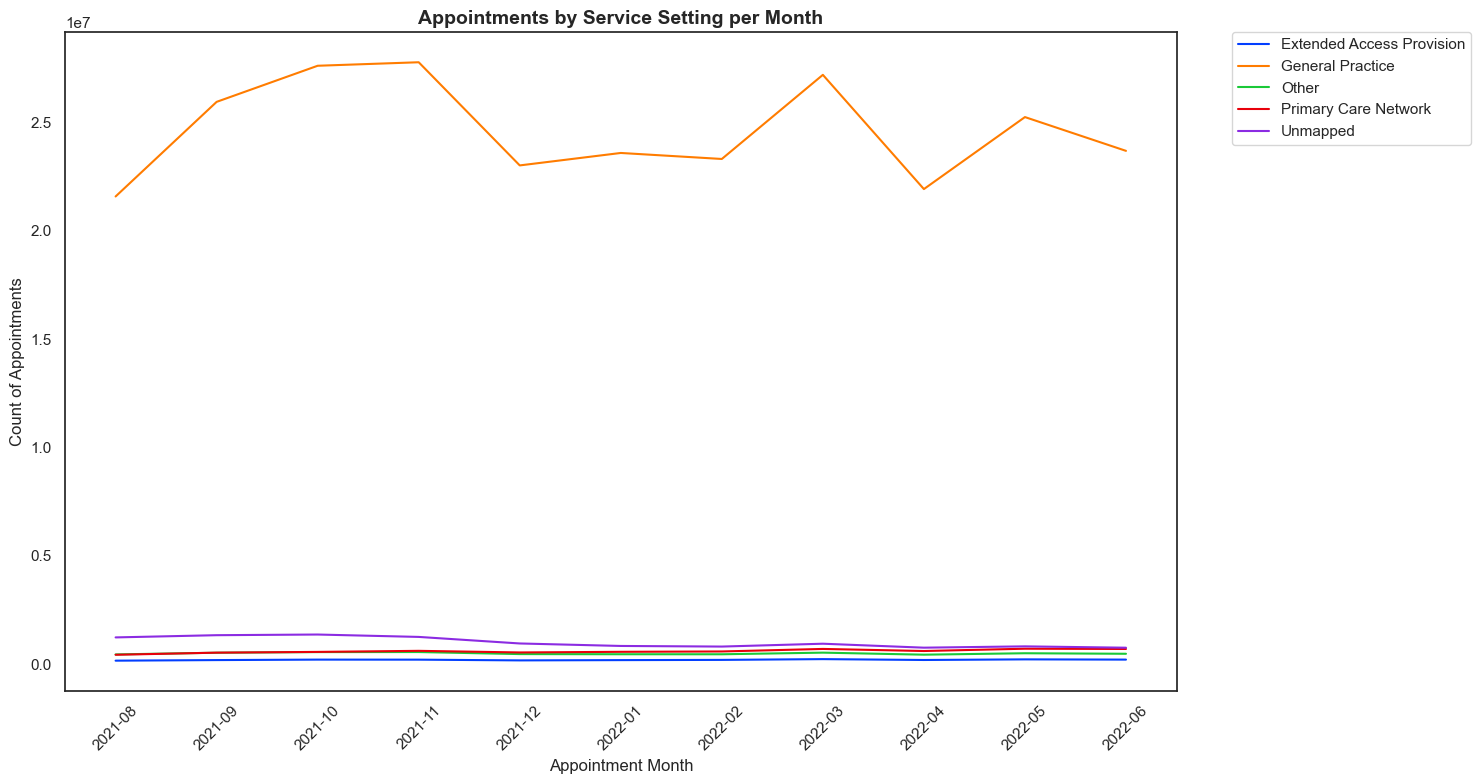

In [32]:
# Plot the appointments over the available date range, and review the service settings for months.
# Create a lineplot.
plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_month',
             y='count_of_appointments',
             hue='service_setting',
             data=nc_ss,
             errorbar=None,
             palette='bright')

plt.title('Appointments by Service Setting per Month', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('service_settings_monthly.png', bbox_inches='tight', dpi=100)
plt.show()

**Observations – Service Settings per Month:**
General Practice dominates all other service settings by a very significant margin (~91.5% of all appointments), making the chart heavily skewed toward a single line. The GP line follows the seasonal appointment trend with peaks in **October/November 2021** and **March 2022**, and a dip in December/January. The 'Unmapped' category shows a notable decline throughout the analysis period, likely indicating that NHS data recording practices improved during this time. A second visualisation excluding GP is created in Activity 6 to examine remaining settings more clearly.

**Context types:**

In [33]:
# Create a separate data set that can be used in future weeks.
nc_ct = nc.groupby(['context_type', 'appointment_month'])['count_of_appointments'].sum().reset_index()

# View output.
print(nc_ct.head(10))

             context_type appointment_month  count_of_appointments
0  Care Related Encounter           2021-08               20255235
1  Care Related Encounter           2021-09               24404251
2  Care Related Encounter           2021-10               26125201
3  Care Related Encounter           2021-11               26282778
4  Care Related Encounter           2021-12               21798612
5  Care Related Encounter           2022-01               22441947
6  Care Related Encounter           2022-02               22211021
7  Care Related Encounter           2022-03               25928850
8  Care Related Encounter           2022-04               20904193
9  Care Related Encounter           2022-05               24101243


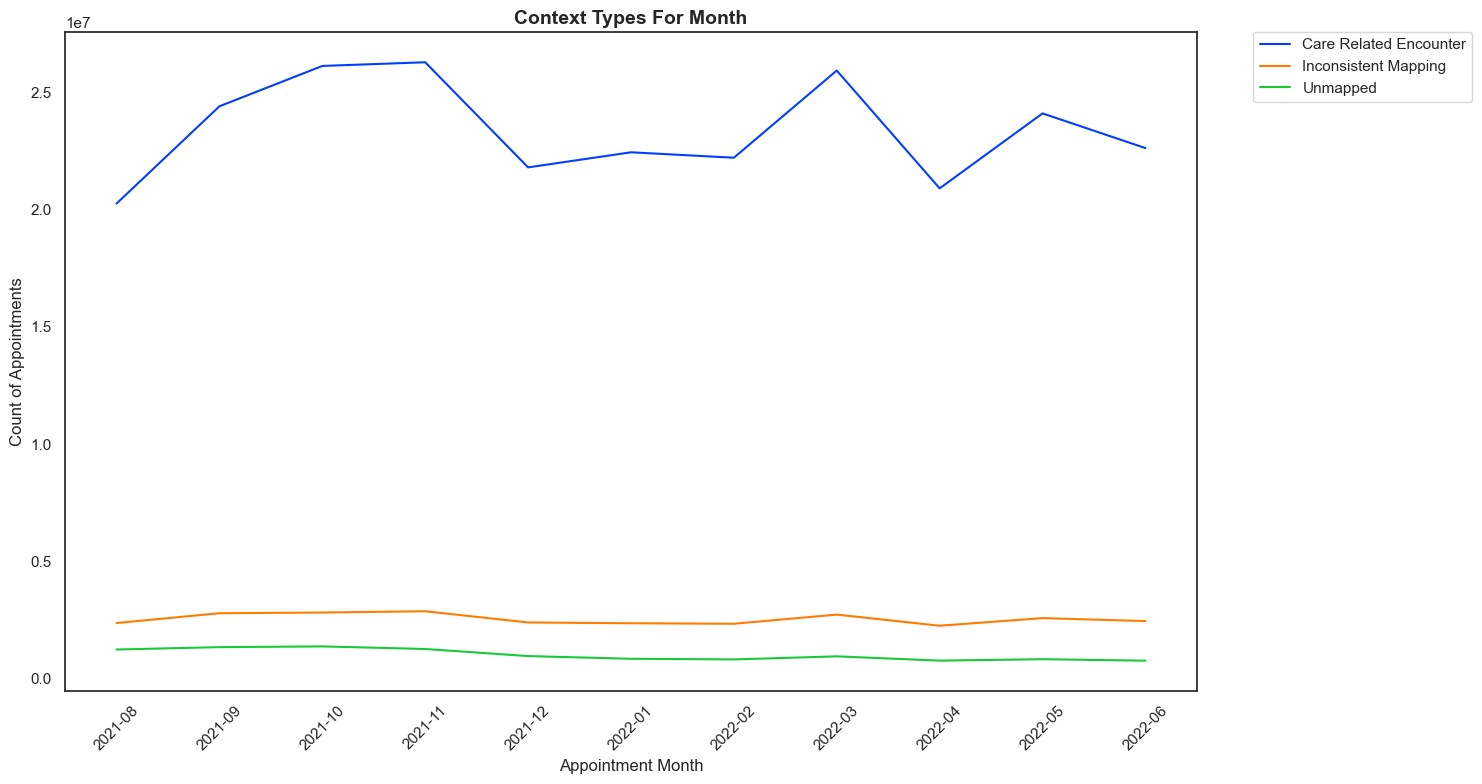

In [34]:
# Plot the appointments over the available date range, and review the context types for months.
# Create a lineplot.
plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_month',
             y='count_of_appointments',
             hue='context_type',
             data=nc_ct,
             errorbar=None,
             palette='bright')

plt.title('Context Types For Month', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('context_types_monthly.png', bbox_inches='tight', dpi=100)
plt.show()

**Observations – Context Types per Month:**
Care Related Encounter accounts for ~86.8% of all appointments and follows the same seasonal pattern as overall appointment volumes — peaking in October/November 2021 and March 2022 with a dip in December–January. Inconsistent Mapping is relatively stable at a much lower level. The 'Unmapped' category shows a significant dip around December 2021–January 2022, coinciding with the period when NHS data quality recording improvements were implemented. This mirrors the 'Unmapped' service setting decline observed above.

**National categories:**

In [35]:
# Create a separate data set that can be used in future weeks.
nc_nc = nc.groupby(['national_category', 'appointment_month'])['count_of_appointments'].sum().reset_index()

# View output.
print(nc_nc.head(10))

                                   national_category appointment_month  \
0  Care Home Needs Assessment & Personalised Care...           2021-08   
1  Care Home Needs Assessment & Personalised Care...           2021-09   
2  Care Home Needs Assessment & Personalised Care...           2021-10   
3  Care Home Needs Assessment & Personalised Care...           2021-11   
4  Care Home Needs Assessment & Personalised Care...           2021-12   
5  Care Home Needs Assessment & Personalised Care...           2022-01   
6  Care Home Needs Assessment & Personalised Care...           2022-02   
7  Care Home Needs Assessment & Personalised Care...           2022-03   
8  Care Home Needs Assessment & Personalised Care...           2022-04   
9  Care Home Needs Assessment & Personalised Care...           2022-05   

   count_of_appointments  
0                  29676  
1                  33503  
2                  32441  
3                  38827  
4                  34653  
5                  3798

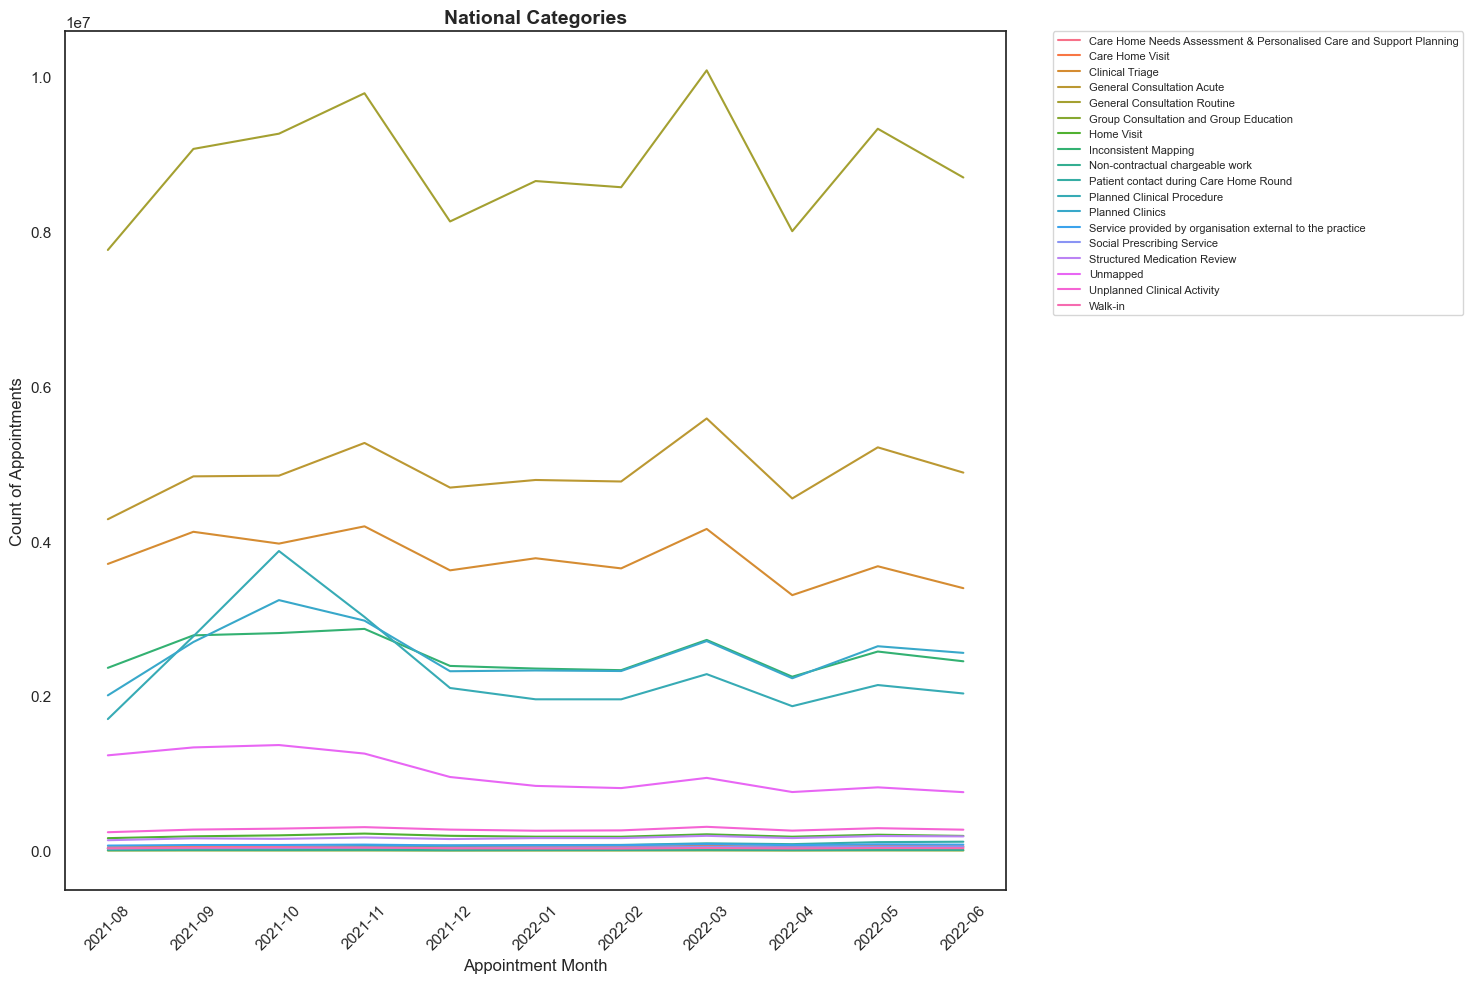

In [36]:
# Plot the appointments over the available date range, and review the national categories for months.
# Create a lineplot.
plt.figure(figsize=(15, 10))
sns.lineplot(x='appointment_month',
             y='count_of_appointments',
             hue='national_category',
             data=nc_nc,
             errorbar=None)

plt.title('National Categories', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.savefig('national_categories_monthly.png', bbox_inches='tight', dpi=100)
plt.show()

**Observations – National Categories per Month:**
With 18 categories the chart is dense, but key trends emerge. **General Consultation Routine** is by far the most common category (≈32.9%), followed by **General Consultation Acute** (≈18.1%). Together, these two consultation types account for over 50% of all appointments. Notable trends include: **Structured Medication Review, Home Visit, and Patient Contact During Care Home Round** all show steady increases across the period; **Walk-in** appointments decline significantly from October 2021 onwards. The large **Inconsistent Mapping** category (consistently high) indicates that many appointment types do not neatly fit the NHS's predefined categories — a data quality concern worth noting.

### Objective 2
Create four visualisations indicating the number of appointments for service setting per season.

In [37]:
# Create a separate data set that can be used in future weeks.
# Group by appointment_date, appointment_month, and service_setting.
nc_ss_day = nc.groupby(['appointment_date', 'appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# View output.
print(nc_ss_day.head())
print(f"Shape: {nc_ss_day.shape}")

  appointment_date appointment_month            service_setting  \
0       2021-08-01           2021-08  Extended Access Provision   
1       2021-08-01           2021-08           General Practice   
2       2021-08-01           2021-08                      Other   
3       2021-08-01           2021-08       Primary Care Network   
4       2021-08-01           2021-08                   Unmapped   

   count_of_appointments  
0                    438  
1                   3411  
2                    401  
3                    323  
4                   1054  
Shape: (1670, 4)


**Summer (June to August 2021):**

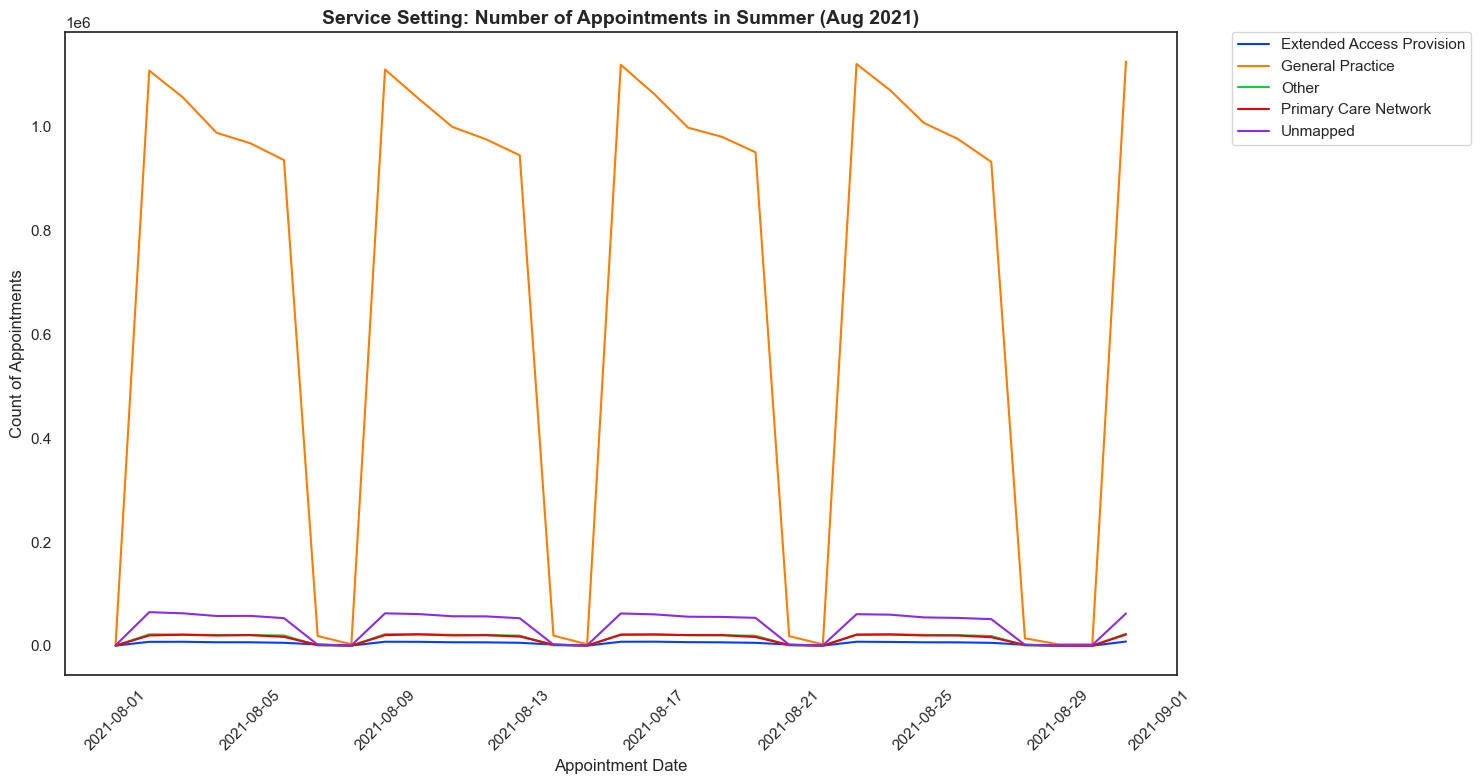

In [38]:
# Look at June to August 2021 in more detail to allow a closer look.
# Note: NC data starts from August 2021. June and July 2021 are not available in this dataset.
summer_months = ['2021-06', '2021-07', '2021-08']
nc_summer = nc_ss_day[nc_ss_day['appointment_month'].isin(summer_months)]

# Create a lineplot.
plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_date',
             y='count_of_appointments',
             hue='service_setting',
             data=nc_summer,
             errorbar=None,
             palette='bright')

plt.title('Service Setting: Number of Appointments in Summer (Aug 2021)', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Date', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('summer_2021.png', bbox_inches='tight', dpi=100)
plt.show()

**Observations – Summer 2021 (August only):**
The NC dataset begins in August 2021, so June and July data is unavailable — this is a data limitation, not a code error. The chart shows August 2021 only. A clear **weekly cycle** is visible: appointment counts spike sharply at the start of each week (Monday) and drop to near-zero at weekends. This pattern is consistent across all service settings, reflecting the predominately Monday-to-Friday operating model of NHS primary care. Summer volumes are the lowest of the year, with daily GP appointments typically below 1 million.

**Autumn (September to November 2021):**

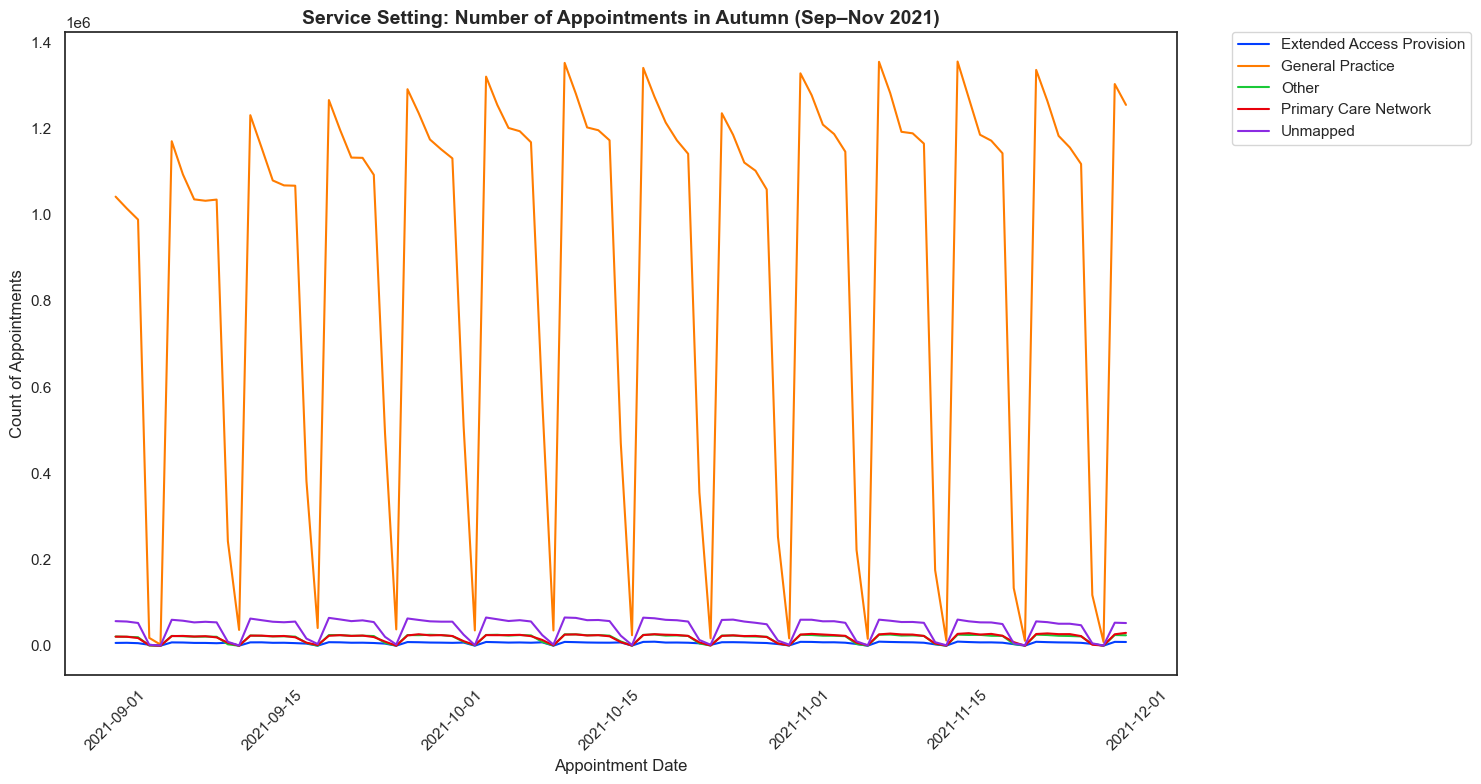

In [39]:
# Look at September to November 2021 in more detail to allow a closer look.
# Create a lineplot.
autumn_months = ['2021-09', '2021-10', '2021-11']
nc_autumn = nc_ss_day[nc_ss_day['appointment_month'].isin(autumn_months)]

plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_date',
             y='count_of_appointments',
             hue='service_setting',
             data=nc_autumn,
             errorbar=None,
             palette='bright')

plt.title('Service Setting: Number of Appointments in Autumn (Sep–Nov 2021)', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Date', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('autumn_2021.png', bbox_inches='tight', dpi=100)
plt.show()

**Observations – Autumn 2021:**
Autumn 2021 was the **busiest season** of the dataset, with October and November recording the highest appointment counts. The weekly sawtooth pattern is most pronounced here with sharp Monday spikes and near-zero weekends. GP appointments regularly exceed 1.2 million per working day in October and November — approaching and occasionally reaching the NHS stated daily capacity limit. This is the season where demand most closely approaches capacity, making it the highest-risk period for service strain.

**Winter (December to February 2022):**

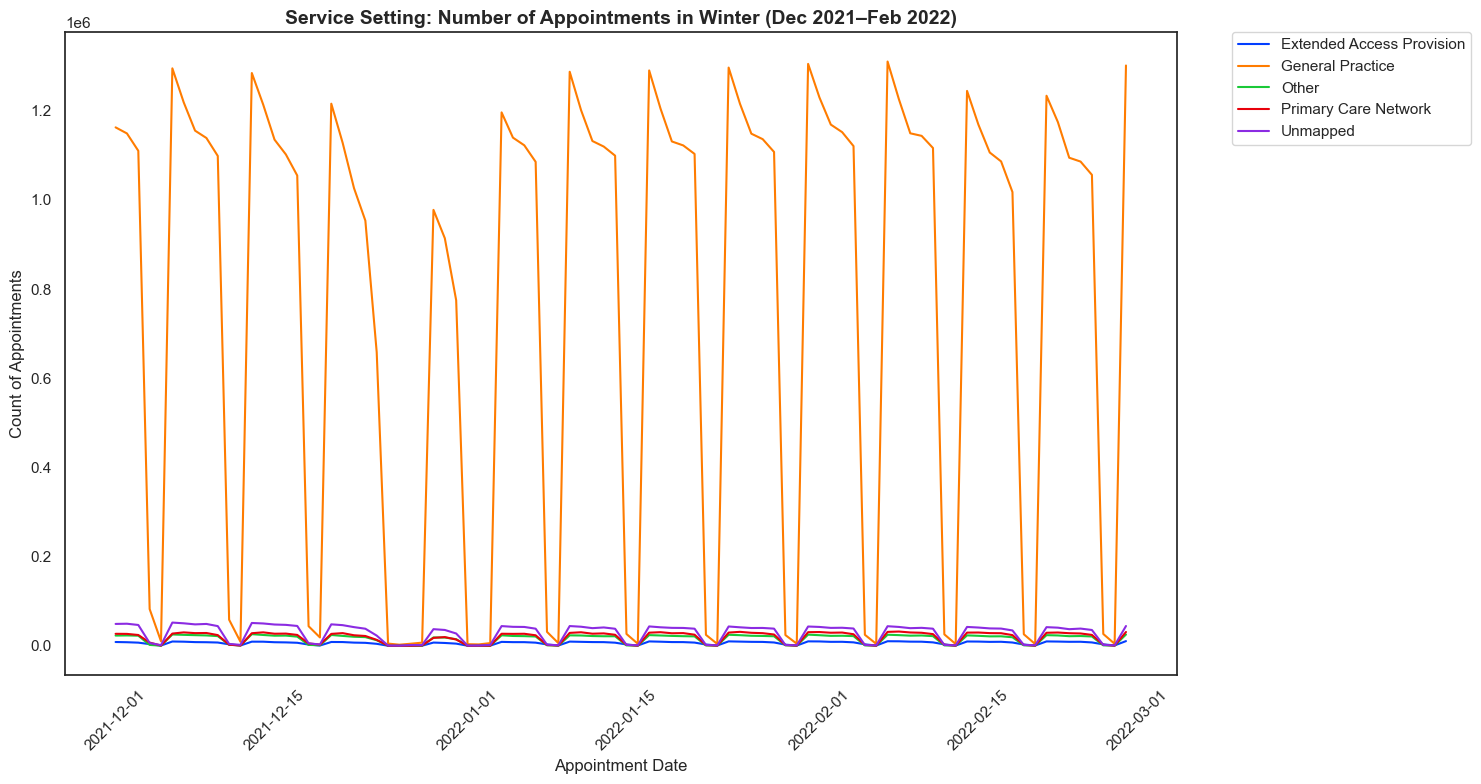

In [40]:
# Look at December to February 2022 in more detail to allow a closer look.
# Create a lineplot.
winter_months = ['2021-12', '2022-01', '2022-02']
nc_winter = nc_ss_day[nc_ss_day['appointment_month'].isin(winter_months)]

plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_date',
             y='count_of_appointments',
             hue='service_setting',
             data=nc_winter,
             errorbar=None,
             palette='bright')

plt.title('Service Setting: Number of Appointments in Winter (Dec 2021–Feb 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Date', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('winter_2022.png', bbox_inches='tight', dpi=100)
plt.show()

**Observations – Winter 2021/2022:**
A notable **dip over the Christmas/New Year period** (late December to early January) is clearly visible, followed by a strong recovery in January. The holiday dip reflects reduced NHS operational capacity rather than reduced patient demand — healthcare need does not pause over public holidays. January 2022 shows a rapid bounce-back to near-autumn levels. February 2022 is relatively stable. The overall winter baseline is lower than autumn, suggesting that some demand which might otherwise occur in winter was suppressed by the ongoing post-pandemic adjustment period.

**Spring (March to May 2022):**

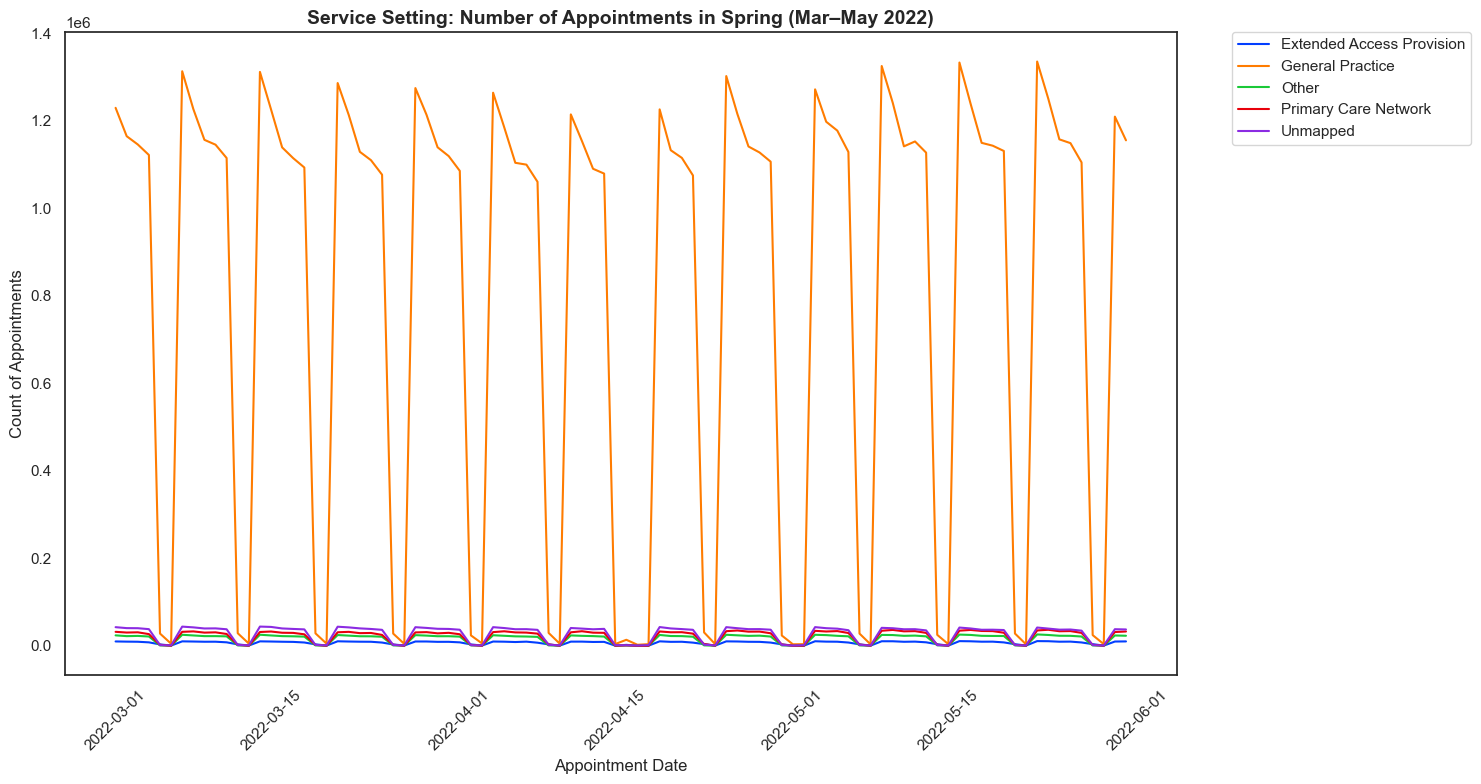

In [41]:
# Look at March to May 2022 in more detail to allow a closer look.
# Create a lineplot.
spring_months = ['2022-03', '2022-04', '2022-05']
nc_spring = nc_ss_day[nc_ss_day['appointment_month'].isin(spring_months)]

plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_date',
             y='count_of_appointments',
             hue='service_setting',
             data=nc_spring,
             errorbar=None,
             palette='bright')

plt.title('Service Setting: Number of Appointments in Spring (Mar–May 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Date', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('spring_2022.png', bbox_inches='tight', dpi=100)
plt.show()

**Observations – Spring 2022:**
**March 2022 shows the second-highest appointment peak** of the entire dataset. This coincides with the full lifting of COVID-19 restrictions in England, which likely triggered a surge in patients seeking appointments that had been deferred during the pandemic. April includes the Easter public holiday period, which creates a visible dip followed by recovery. May 2022 stabilises at moderate levels. The spring pattern, combined with the autumn peak, confirms a **bimodal seasonal pattern** in NHS demand — two peaks per year (autumn and spring) with summer as the trough.

**Overall Activity 4 Summary:**
Across all four seasons, a consistent **weekly sawtooth pattern** emerges: peaks Monday–Wednesday, decline Thursday–Friday, near-zero at weekends. Autumn is the busiest season; summer the quietest. General Practice dominates every season. The data suggests the NHS operates on a firmly Monday–Friday model, raising the question of whether extended weekend capacity could better distribute demand.

#

# Assignment Activity 5

### Analyse tweets from Twitter with hashtags related to healthcare in the UK.

In [42]:
# Libraries and settings needed for analysis.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize': (15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display.
pd.options.display.max_colwidth = 200

In [43]:
# Load the data set.
tweets = pd.read_csv('tweets.csv')

# View the DataFrame.
tweets.head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en


In [44]:
# Explore the metadata.
print(tweets.info())
print()
print(tweets.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB
None

tweet_id                    int64
tweet_full_text            object
tweet_entities             object
tweet_entities_hashtags    object
tweet_metadata             object
tweet_retweet_count  

In [45]:
# Explore the data set.
tweets.describe(include='all')

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
count,1.174000e+03,1174,1174,1007,1174,1174.000000,1174.00000,1174,1174,1174
unique,NaN,961,945,710,1,NaN,NaN,1,1,1
top,NaN,"RT @khaleejtimes: .@BurjeelHoldings, a private healthcare services provider, has partnered with superstar @iamsrk as its new brand ambassad…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'khaleejtimes', 'name': 'Khaleej Times', 'id': 18860860, 'id_str': '18860860', 'indices': [3, 16]}, {'screen_name': 'BurjeelHoldin...",#healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",NaN,NaN,False,False,en
freq,NaN,15,15,88,1174,NaN,NaN,1174,1174,1174
mean,1.567612e+18,NaN,NaN,NaN,NaN,8.629472,0.37138,NaN,NaN,NaN
std,2.427553e+13,NaN,NaN,NaN,NaN,29.784675,2.04470,NaN,NaN,NaN
min,1.567574e+18,NaN,NaN,NaN,NaN,0.000000,0.00000,NaN,NaN,NaN
25%,1.567590e+18,NaN,NaN,NaN,NaN,0.000000,0.00000,NaN,NaN,NaN
50%,1.567611e+18,NaN,NaN,NaN,NaN,1.000000,0.00000,NaN,NaN,NaN
75%,1.567633e+18,NaN,NaN,NaN,NaN,3.000000,0.00000,NaN,NaN,NaN


In [46]:
# Would it be useful to only look at retweeted and favourite tweet messages?
# Explore the tweet_retweet_count and tweet_favorite_count columns with value_counts().
print("Retweet count distribution (top 10 values):")
print(tweets['tweet_retweet_count'].value_counts().head(10))
print()
print("Favorite count distribution (top 10 values):")
print(tweets['tweet_favorite_count'].value_counts().head(10))

Retweet count distribution (top 10 values):
tweet_retweet_count
0     526
1     215
2     114
3      70
5      35
4      27
7      18
12     16
8      15
73     14
Name: count, dtype: int64

Favorite count distribution (top 10 values):
tweet_favorite_count
0     1027
1       91
2       16
3       13
4        7
5        5
6        2
17       1
12       1
10       1
Name: count, dtype: int64


**Should we filter to only retweeted/favourite tweets?**
The `tweet_retweet_count` and `tweet_favorite_count` columns indicate how impactful each tweet was. The majority of tweets have 0 retweets and 0 favourites, meaning they had little engagement. **Yes, it would be useful** to filter to tweets with higher engagement counts, as these represent the most visible and influential messages on healthcare topics. However, for hashtag frequency analysis, we will first examine all tweets to understand the full landscape, then create a filtered visualisation removing over-represented hashtags.

In [47]:
# Create a new DataFrame containing only the text.
tweets_text = tweets[['tweet_full_text']].copy()

# View the DataFrame.
tweets_text.head()

,tweet_full_text
0,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be..."
1,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…
2,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…
3,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…
4,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di..."


In [48]:
# Loop through the messages, and create a list of values containing the # symbol.
# Clean each token: only keep tags that START with # and contain only alphanumeric characters.
import re

tags = []

for y in [x.split(' ') for x in tweets['tweet_full_text'].values]:
    for z in y:
        if '#' in z:
            # Lowercase and strip surrounding punctuation.
            cleaned = z.lower().strip('.,!?;:()"\'\n')
            # Only keep tokens that start with # and are purely alphanumeric after the #.
            if re.match(r'^#[a-z0-9]+$', cleaned):
                tags.append(cleaned)

In [49]:
# Display the first 30 records.
print(tags[:30])

['#healthcare', '#premisehealth', '#hiring', '#healthcare', '#digitaltransformation', '#cybersecurity', '#accounting', '#finance', '#healthcare', '#cnaexam', '#cnaexampreparation', '#jacksonville', '#cnatraining', '#nurse', '#nursing', '#nurselife', '#nursepractitioner', '#nurseproblems', '#nursingschool', '#healthcare', '#disparities', '#alert', '#insurance', '#healthcare', '#healthcare', '#healthcare', '#hcldr', '#premisehealth', '#hiring', '#premisehealth']


In [50]:
# Convert the series to a DataFrame in preparation for visualisation.
tags_series = pd.Series(tags).value_counts().reset_index()

# Rename the columns.
tags_series.columns = ['word', 'count']

In [51]:
# Fix the count datatype.
tags_series['count'] = tags_series['count'].astype(int)

# View the result.
print(tags_series.head(20))

                        word  count
0                #healthcare    769
1                    #health     83
2                        #ai     44
3                  #medicine     42
4                       #job     38
5                   #medical     35
6                  #strategy     30
7             #digitalhealth     29
8            #pharmaceutical     28
9                    #pharma     25
10                  #biotech     25
11                #marketing     25
12  #competitiveintelligence     24
13               #medtwitter     24
14                    #meded     23
15               #technology     18
16                  #vaccine     18
17                   #hiring     18
18                     #news     17
19          #machinelearning     17


In [52]:
# Display records where the count is larger than 10.
tags_filtered = tags_series[tags_series['count'] > 10]
print(f"Hashtags appearing more than 10 times: {len(tags_filtered)}")
print(tags_filtered.to_string(index=False))

Hashtags appearing more than 10 times: 47
                       word  count
                #healthcare    769
                    #health     83
                        #ai     44
                  #medicine     42
                       #job     38
                   #medical     35
                  #strategy     30
             #digitalhealth     29
            #pharmaceutical     28
                    #pharma     25
                   #biotech     25
                 #marketing     25
   #competitiveintelligence     24
                #medtwitter     24
                     #meded     23
                #technology     18
                   #vaccine     18
                    #hiring     18
                      #news     17
           #machinelearning     17
                     #covid     17
           #womeninmedicine     16
      #competitivemarketing     16
               #coronavirus     16
                #healthtech     15
                  #wellness     15
             

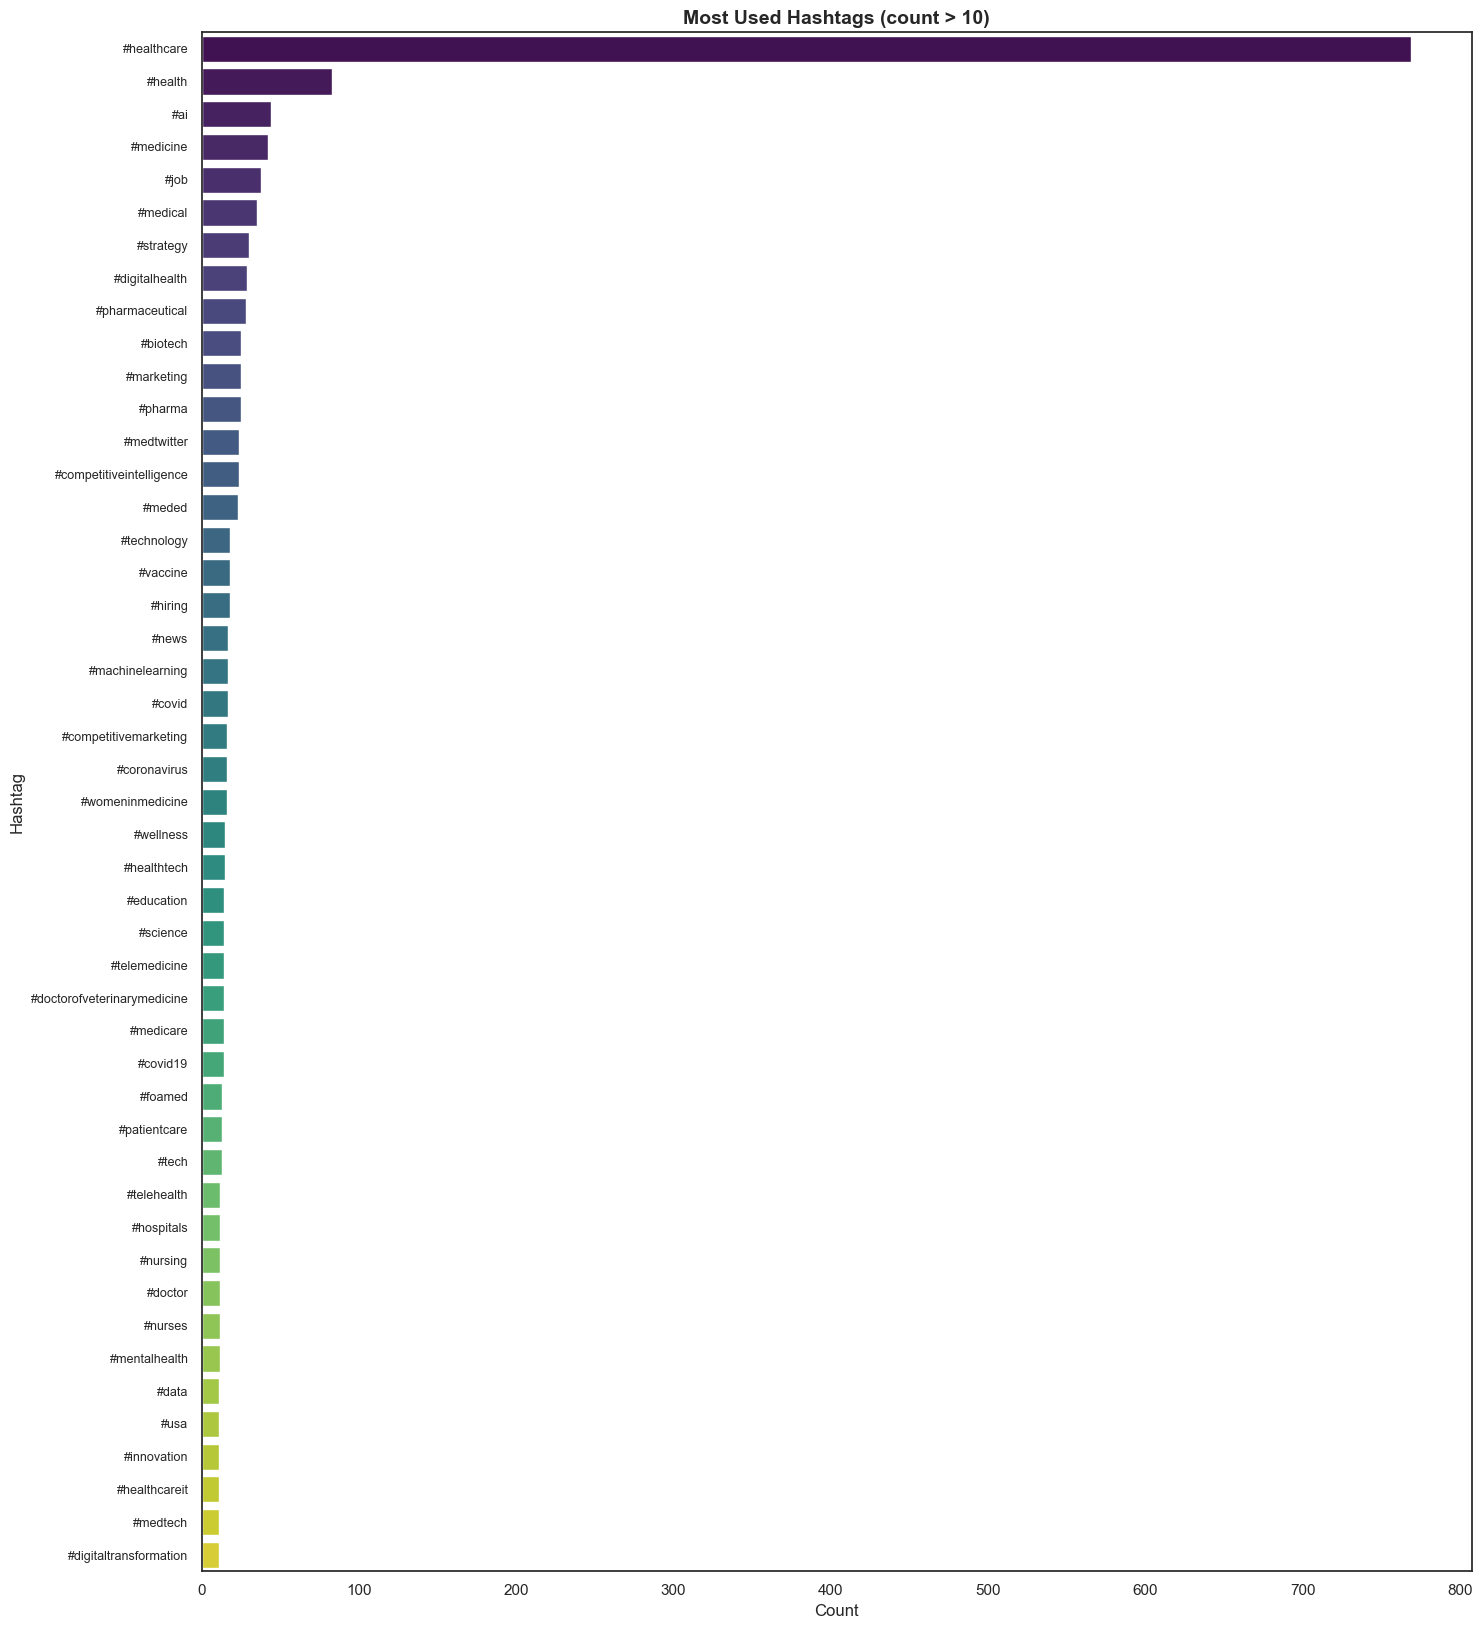

In [53]:
# Create a Seaborn barplot indicating records with a count > 10 records.
# Create the plot.
# Figure height is set dynamically to prevent y-axis label overlap.
fig_height = max(10, len(tags_filtered) * 0.35)
plt.figure(figsize=(15, fig_height))
sns.barplot(x='count',
            y='word',
            data=tags_filtered.sort_values('count', ascending=False),
            palette='viridis')

plt.title('Most Used Hashtags (count > 10)', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Hashtag', fontsize=12)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('hashtags_all.png', bbox_inches='tight', dpi=100)

# View the barplot.
plt.show()

**Observations – Twitter Hashtag Analysis (All hashtags > 10):**
`#healthcare` is the most frequently occurring hashtag by a substantial margin (**769 occurrences**), followed by `#health` (83) and `#ai` (44). The dominance of `#healthcare` suggests strong public and professional interest in NHS-related topics on social media. Other notable hashtags include `#medicine` (42), `#job` (38), `#medical`, `#strategy`, `#digitalhealth` (29), and `#pharmaceutical` — indicating that the Twitter conversation around healthcare is broad, encompassing technology, careers, and pharmaceutical topics alongside core NHS discussions.

To better understand the distribution beyond the dominant `#healthcare`, a second chart is created below excluding it.

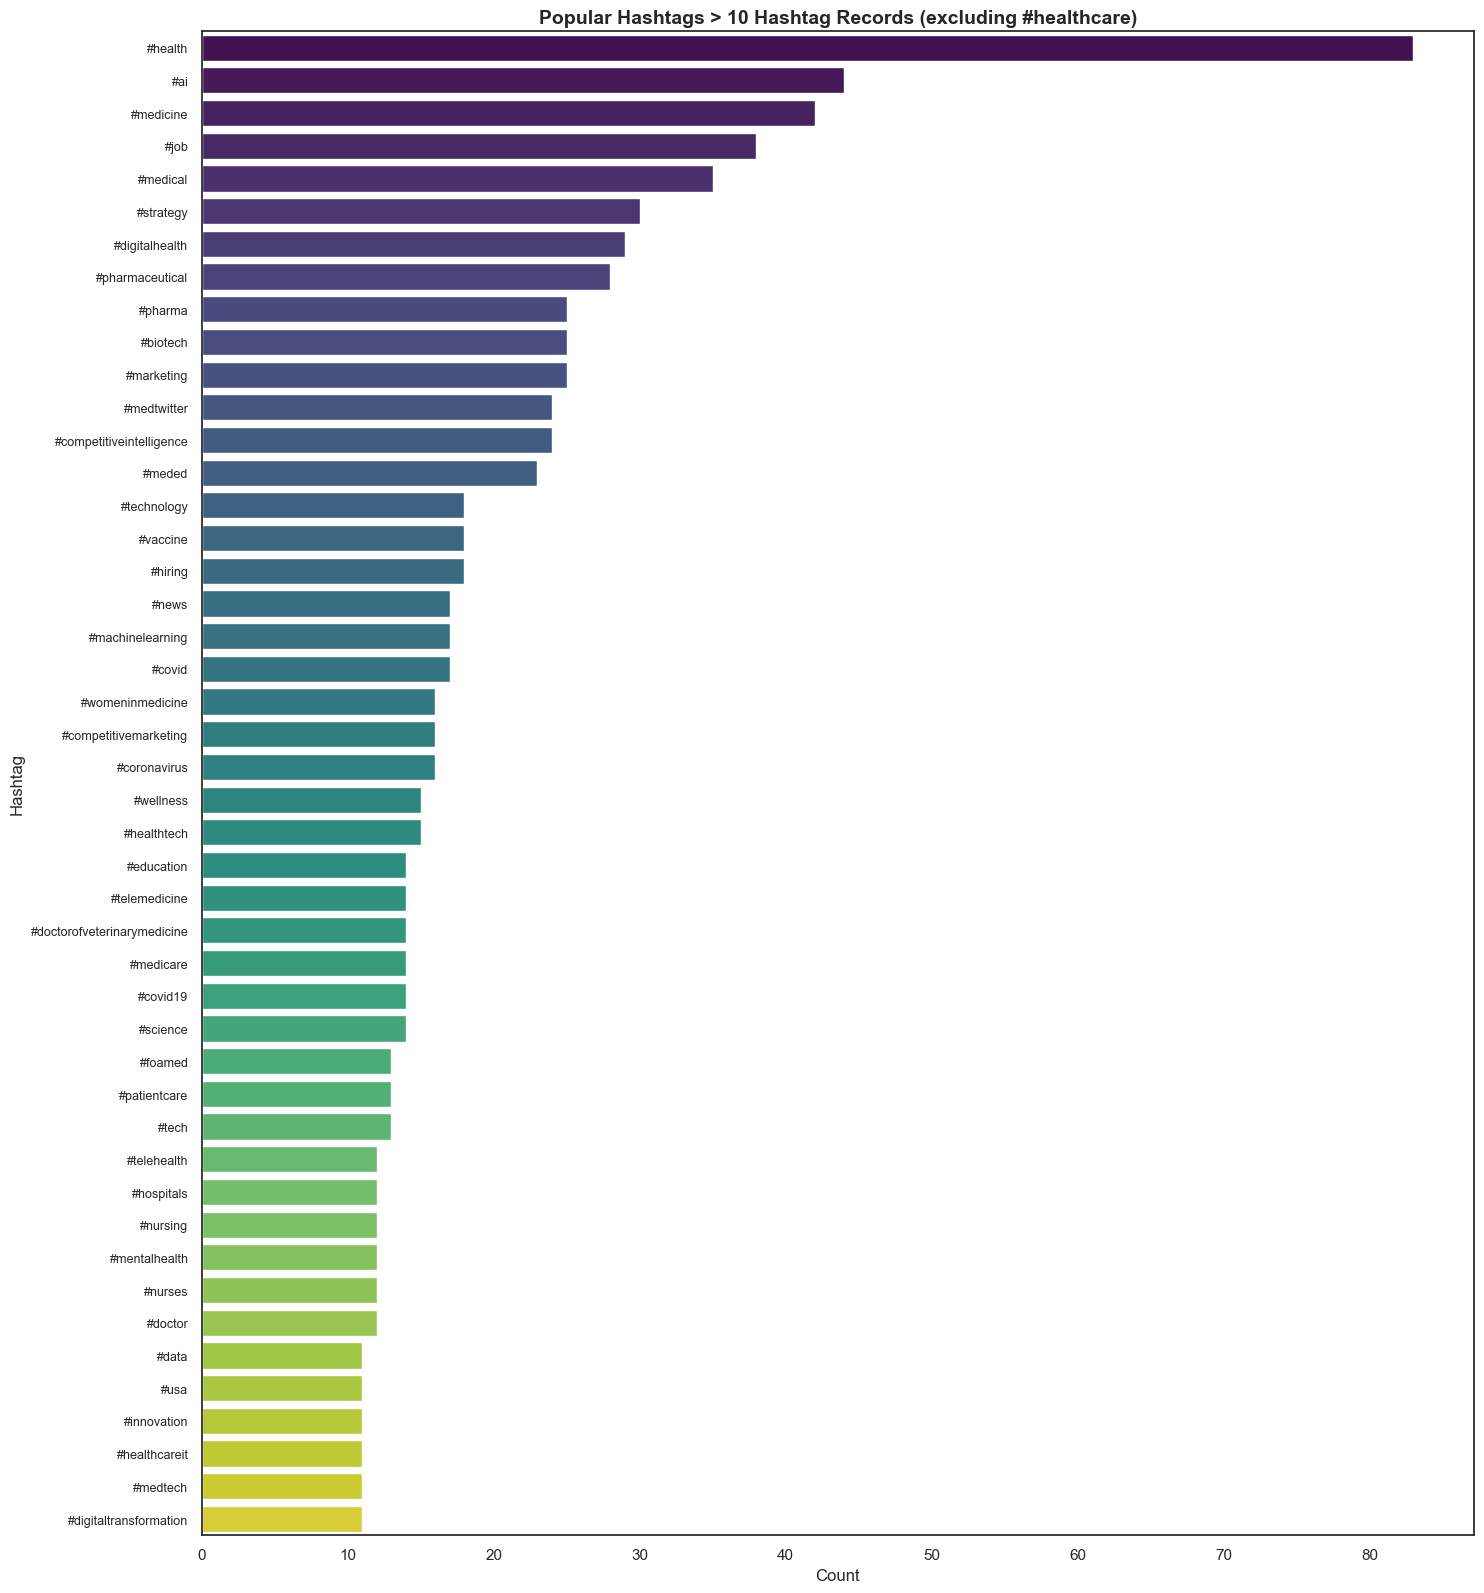

In [54]:
# Remove the overrepresented #healthcare hashtag and re-plot the remaining hashtags.
tags_exc_healthcare = tags_filtered[tags_filtered['word'] != '#healthcare']

# Figure height is set dynamically to prevent y-axis label overlap.
fig_height = max(10, len(tags_exc_healthcare) * 0.35)
plt.figure(figsize=(15, fig_height))
sns.barplot(x='count',
            y='word',
            data=tags_exc_healthcare.sort_values('count', ascending=False),
            palette='viridis')

plt.title('Popular Hashtags > 10 Hashtag Records (excluding #healthcare)', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Hashtag', fontsize=12)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('hashtags_exc_healthcare.png', bbox_inches='tight', dpi=100)
plt.show()

**Observations – Hashtags Excluding #healthcare:**
With `#healthcare` removed, the visualisation reveals a richer picture of the healthcare conversation on Twitter/X. `#health` leads with **83 occurrences**, followed by `#ai` (44), `#medicine` (42), and `#job` (38). The presence of `#ai`, `#digitalhealth` (29), `#machinelearning`, and `#healthtech` indicates a growing conversation around digital transformation in healthcare — highly relevant for the NHS's strategic direction. `#job` (38) and `#hiring` (18) suggest significant discussion around NHS staffing and recruitment, which directly supports the business question of whether NHS staffing levels are adequate. `#covid`, `#coronavirus`, and `#covid19` reflect the ongoing pandemic context.

#

# Assignment Activity 6

### Make recommendations to the NHS.

In [55]:
# Prepare your workstation.
# Load the appointments_regional.csv file fresh.
ar = pd.read_csv('appointments_regional.csv')
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'])

# View the DataFrame.
display(ar.head())

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [56]:
# Print the min and max dates.
print(f"AR - Earliest month: {ar['appointment_month'].min().strftime('%Y-%m')}")
print(f"AR - Latest month  : {ar['appointment_month'].max().strftime('%Y-%m')}")

AR - Earliest month: 2020-01
AR - Latest month  : 2022-06


In [57]:
# Filter the data set to only look at data from 2021-08 onwards.
ar2 = ar[ar['appointment_month'] >= '2021-08-01'].copy()
print(f"Filtered AR shape: {ar2.shape}")
print(f"Date range: {ar2['appointment_month'].min().strftime('%Y-%m')} to {ar2['appointment_month'].max().strftime('%Y-%m')}")

Filtered AR shape: (223418, 7)
Date range: 2021-08 to 2022-06


**Question 1:** Should the NHS start looking at increasing staff levels?

In [58]:
# Create an aggregated data set to review the different features.
ar_agg = ar2[['appointment_month', 'hcp_type', 'appointment_status',
              'appointment_mode', 'time_between_book_and_appointment',
              'count_of_appointments']].copy()

# View the DataFrame.
display(ar_agg.head(10))

,appointment_month,hcp_type,appointment_status,appointment_mode,time_between_book_and_appointment,count_of_appointments
3652,2021-08-01,GP,Attended,Face-to-Face,1 Day,6553
3653,2021-08-01,GP,Attended,Face-to-Face,15 to 21 Days,2390
3654,2021-08-01,GP,Attended,Face-to-Face,2 to 7 Days,10547
3655,2021-08-01,GP,Attended,Face-to-Face,22 to 28 Days,937
3656,2021-08-01,GP,Attended,Face-to-Face,8 to 14 Days,4961
3657,2021-08-01,GP,Attended,Face-to-Face,More than 28 Days,445
3658,2021-08-01,GP,Attended,Face-to-Face,Same Day,40113
3659,2021-08-01,GP,Attended,Face-to-Face,Unknown / Data Quality,15
3660,2021-08-01,GP,Attended,Home Visit,1 Day,169
3661,2021-08-01,GP,Attended,Home Visit,15 to 21 Days,3


In [59]:
# Determine the total number of appointments per month.
ar_agg_gb = ar_agg.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Add a new column to indicate the average utilisation of services.
# Monthly aggregate / 30 to get daily value, then / 1,200,000 (NHS daily capacity) * 100 for %.
ar_agg_gb['daily_avg'] = ar_agg_gb['count_of_appointments'] / 30
ar_agg_gb['utilisation_pct'] = (ar_agg_gb['daily_avg'] / 1_200_000) * 100

# View the DataFrame.
print(ar_agg_gb.to_string(index=False))
print(f"\nMax daily utilisation: {ar_agg_gb['utilisation_pct'].max():.1f}%")
print(f"Average utilisation:   {ar_agg_gb['utilisation_pct'].mean():.1f}%")

appointment_month  count_of_appointments    daily_avg  utilisation_pct
       2021-08-01               23852171 7.950724e+05        66.256031
       2021-09-01               28522501 9.507500e+05        79.229169
       2021-10-01               30303834 1.010128e+06        84.177317
       2021-11-01               30405070 1.013502e+06        84.458528
       2021-12-01               25140776 8.380259e+05        69.835489
       2022-01-01               25635474 8.545158e+05        71.209650
       2022-02-01               25355260 8.451753e+05        70.431278
       2022-03-01               29595038 9.865013e+05        82.208439
       2022-04-01               23913060 7.971020e+05        66.425167
       2022-05-01               27495508 9.165169e+05        76.376411
       2022-06-01               25828078 8.609359e+05        71.744661

Max daily utilisation: 84.5%
Average utilisation:   74.8%


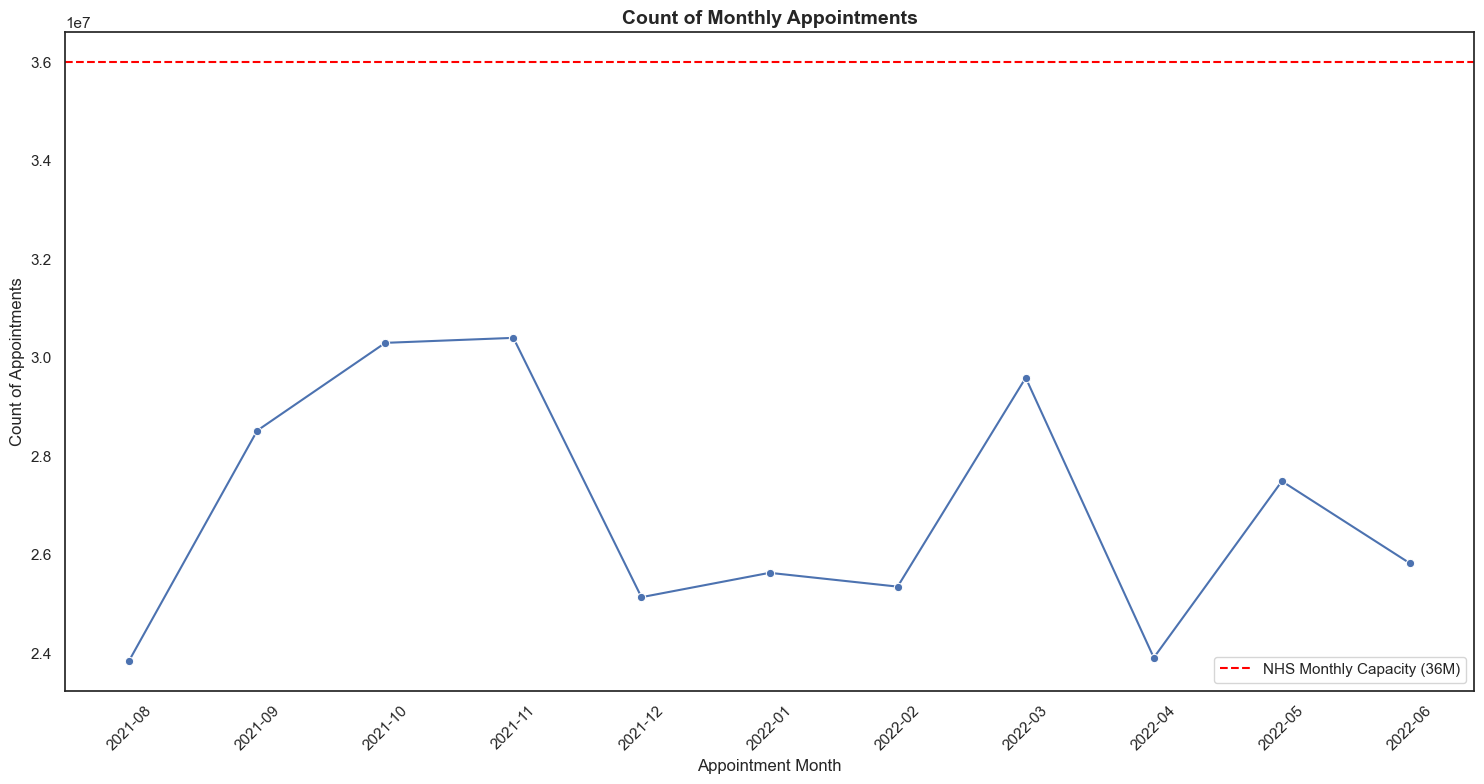

In [60]:
# Plot sum of count of monthly visits.
# Convert the appointment_month to string data type for ease of visualisation.
ar_agg_gb['appointment_month_str'] = ar_agg_gb['appointment_month'].dt.strftime('%Y-%m')

# Create a lineplot with Seaborn.
plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_month_str',
             y='count_of_appointments',
             data=ar_agg_gb,
             marker='o')

# Add NHS monthly capacity reference line (1,200,000/day × 30 = 36,000,000/month).
plt.axhline(y=36_000_000, color='red', linestyle='--', linewidth=1.5, label='NHS Monthly Capacity (36M)')

plt.title('Count of Monthly Appointments', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('monthly_appointments.png', bbox_inches='tight', dpi=100)
plt.show()

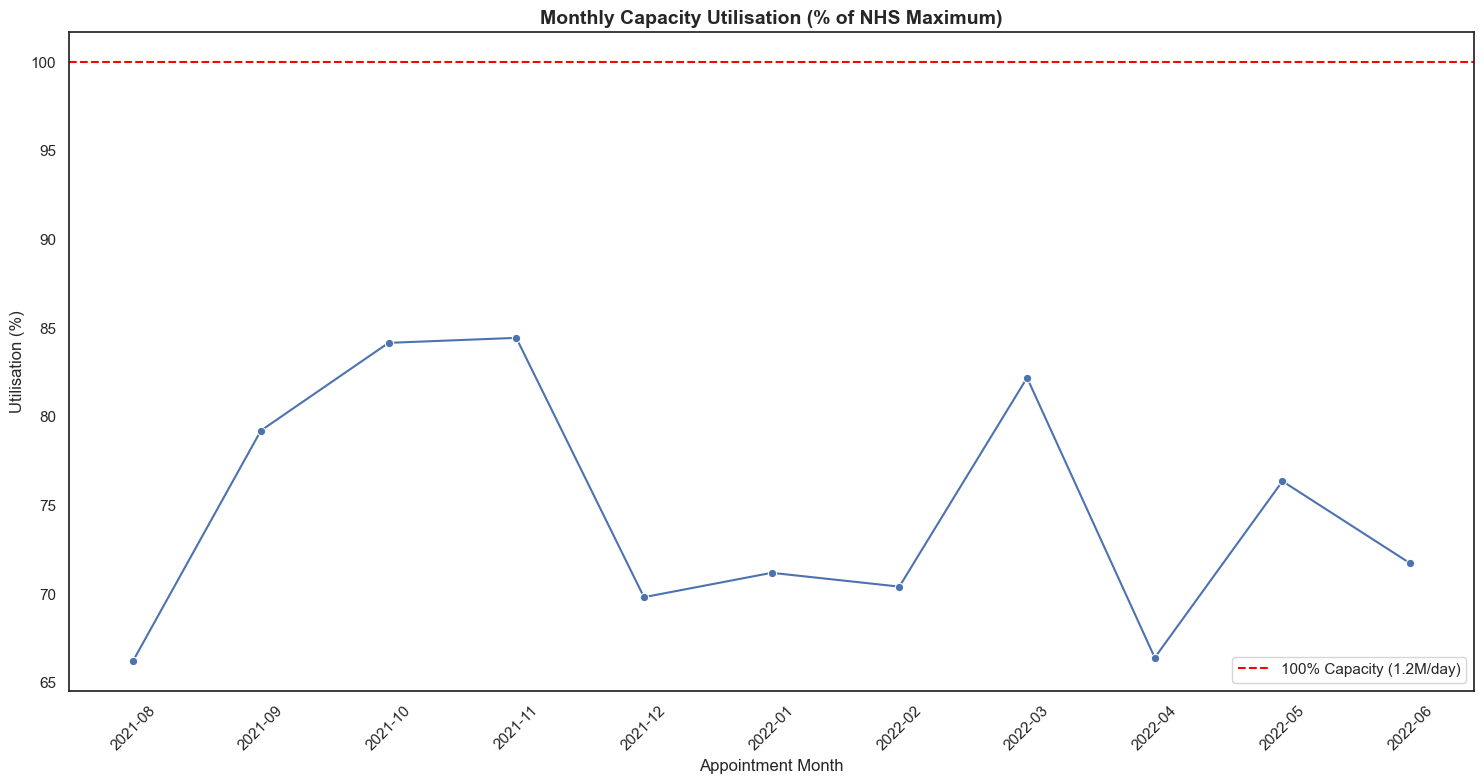

In [61]:
# Plot monthly capacity utilisation.
plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_month_str',
             y='utilisation_pct',
             data=ar_agg_gb,
             marker='o')

# Add 100% capacity reference line.
plt.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='100% Capacity (1.2M/day)')

plt.title('Monthly Capacity Utilisation (% of NHS Maximum)', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Utilisation (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('capacity_utilisation.png', bbox_inches='tight', dpi=100)
plt.show()

**Answer – Should the NHS increase staff levels?**
Based on the capacity utilisation analysis, **the NHS has NOT exceeded its stated daily capacity of 1,200,000 appointments** during the entire analysis period (Aug 2021–Jun 2022). The maximum monthly utilisation reached **84.5%** (November 2021), with a period average of **74.8%** across the analysis period. The daily average never exceeds the 1.2M threshold.

**Conclusion:** While increasing staff would improve resilience, the data does not suggest the NHS is currently overstretched at a national level. However, this analysis has limitations — the 1.2M figure is an unverified aggregate, does not account for regional variation, and does not capture demand that was turned away. A more targeted recommendation would be to investigate **specific regions and time periods** (particularly October/November) where capacity pressures are likely higher.


**Question 2:** How do the healthcare professional types differ over time?

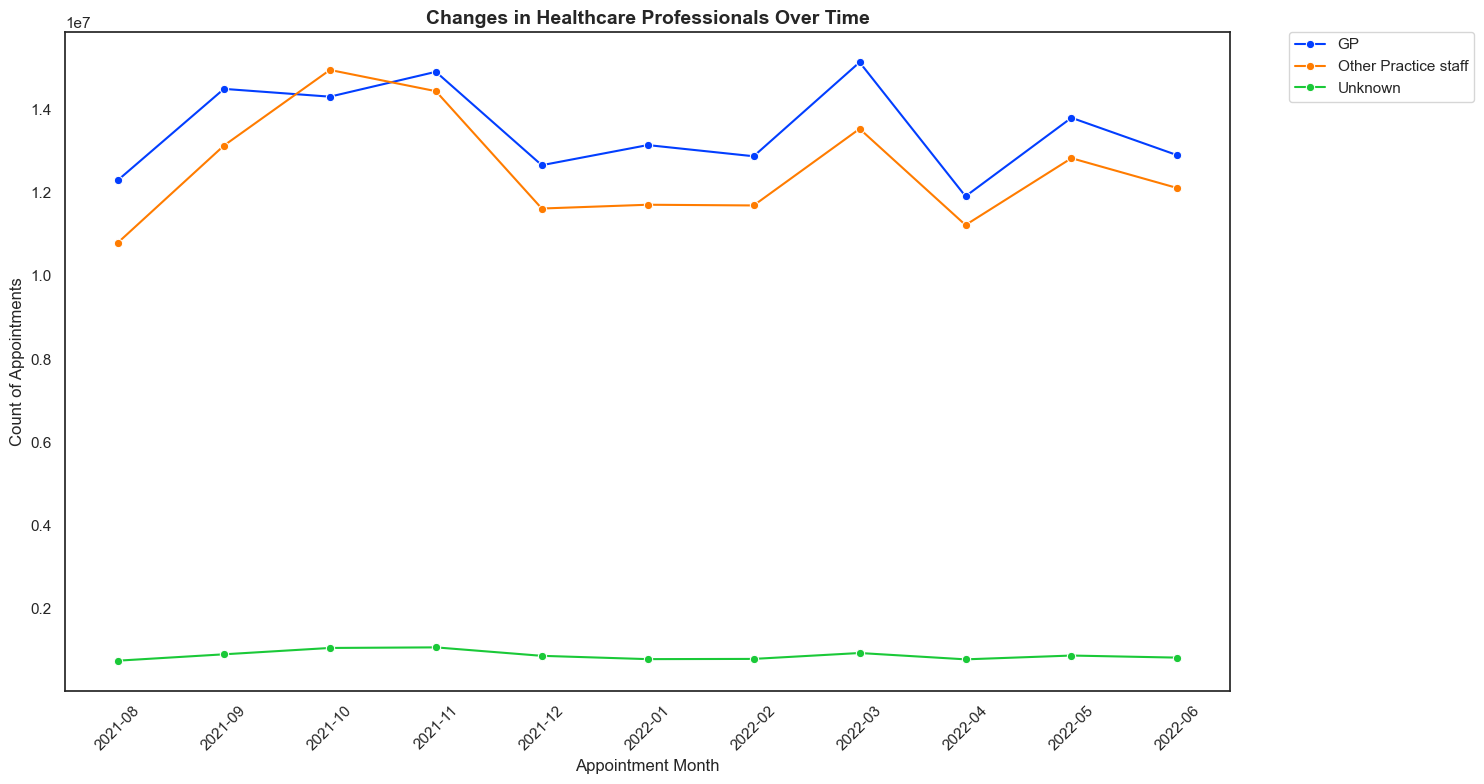

In [62]:
# Create a line plot to answer the question.
ar_hcp = ar_agg.groupby(['appointment_month', 'hcp_type'])['count_of_appointments'].sum().reset_index()
ar_hcp['appointment_month_str'] = ar_hcp['appointment_month'].dt.strftime('%Y-%m')

plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_month_str',
             y='count_of_appointments',
             hue='hcp_type',
             data=ar_hcp,
             errorbar=None,
             palette='bright',
             marker='o')

plt.title('Changes in Healthcare Professionals Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('hcp_over_time.png', bbox_inches='tight', dpi=100)
plt.show()

**Observations – HCP Types Over Time:**
GP and Other Practice Staff follow near-identical seasonal patterns, both peaking in October/November 2021 and March 2022 before declining. This parallel movement suggests demand, not staffing changes, drives the variation. The 'Unknown' HCP category remains consistently low. Notably, **GPs and Other Practice Staff handle roughly similar volumes** of appointments, reflecting the NHS's strategy of using a broader range of clinical staff (nurses, pharmacists, physiotherapists) to manage demand. There is no evidence of a significant structural change in HCP type distribution during the analysis period.

**Question 3:** Are there significant changes in whether or not visits are attended?

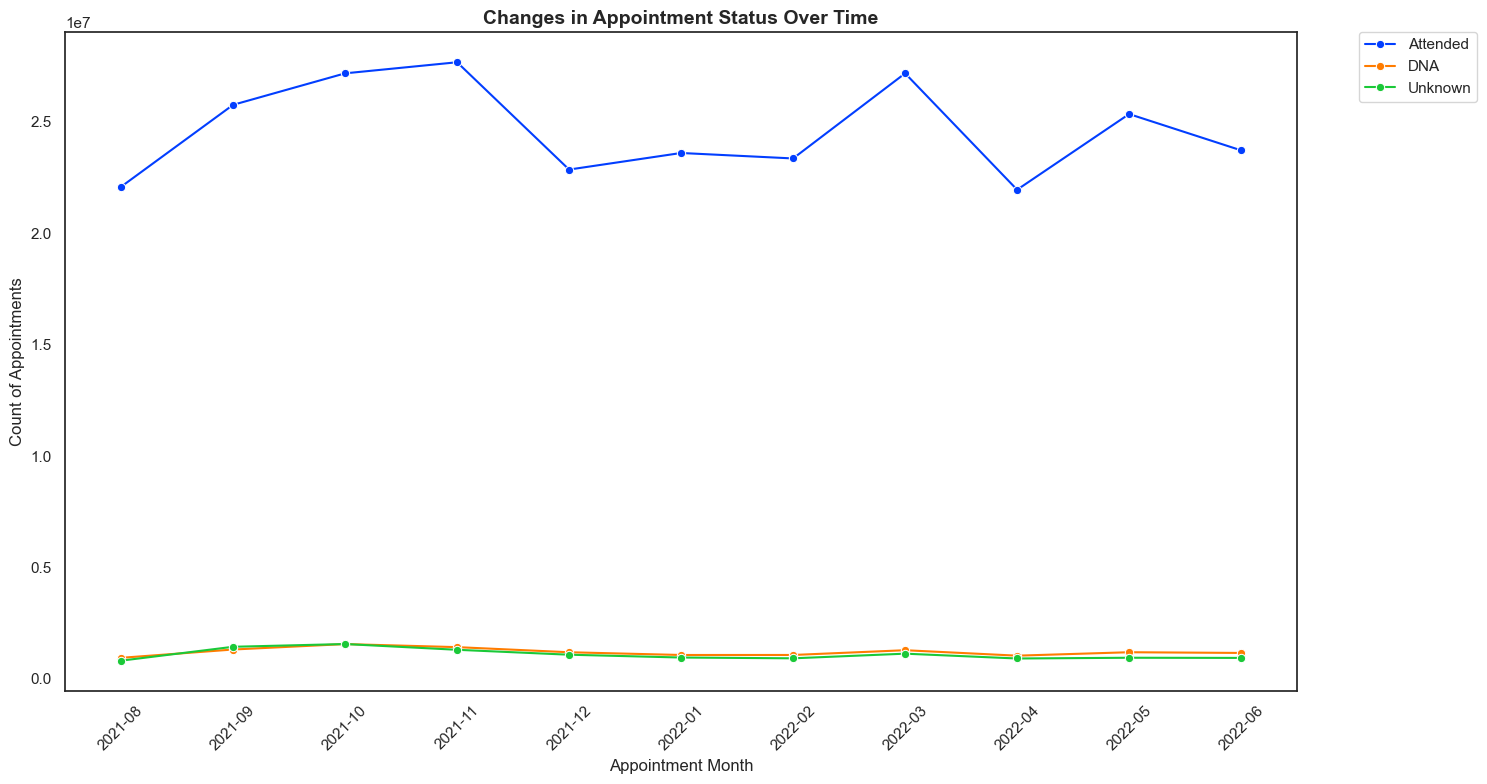

In [63]:
# Create a line plot to answer the question.
ar_status = ar_agg.groupby(['appointment_month', 'appointment_status'])['count_of_appointments'].sum().reset_index()
ar_status['appointment_month_str'] = ar_status['appointment_month'].dt.strftime('%Y-%m')

plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_month_str',
             y='count_of_appointments',
             hue='appointment_status',
             data=ar_status,
             errorbar=None,
             palette='bright',
             marker='o')

plt.title('Changes in Appointment Status Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('appointment_status.png', bbox_inches='tight', dpi=100)
plt.show()

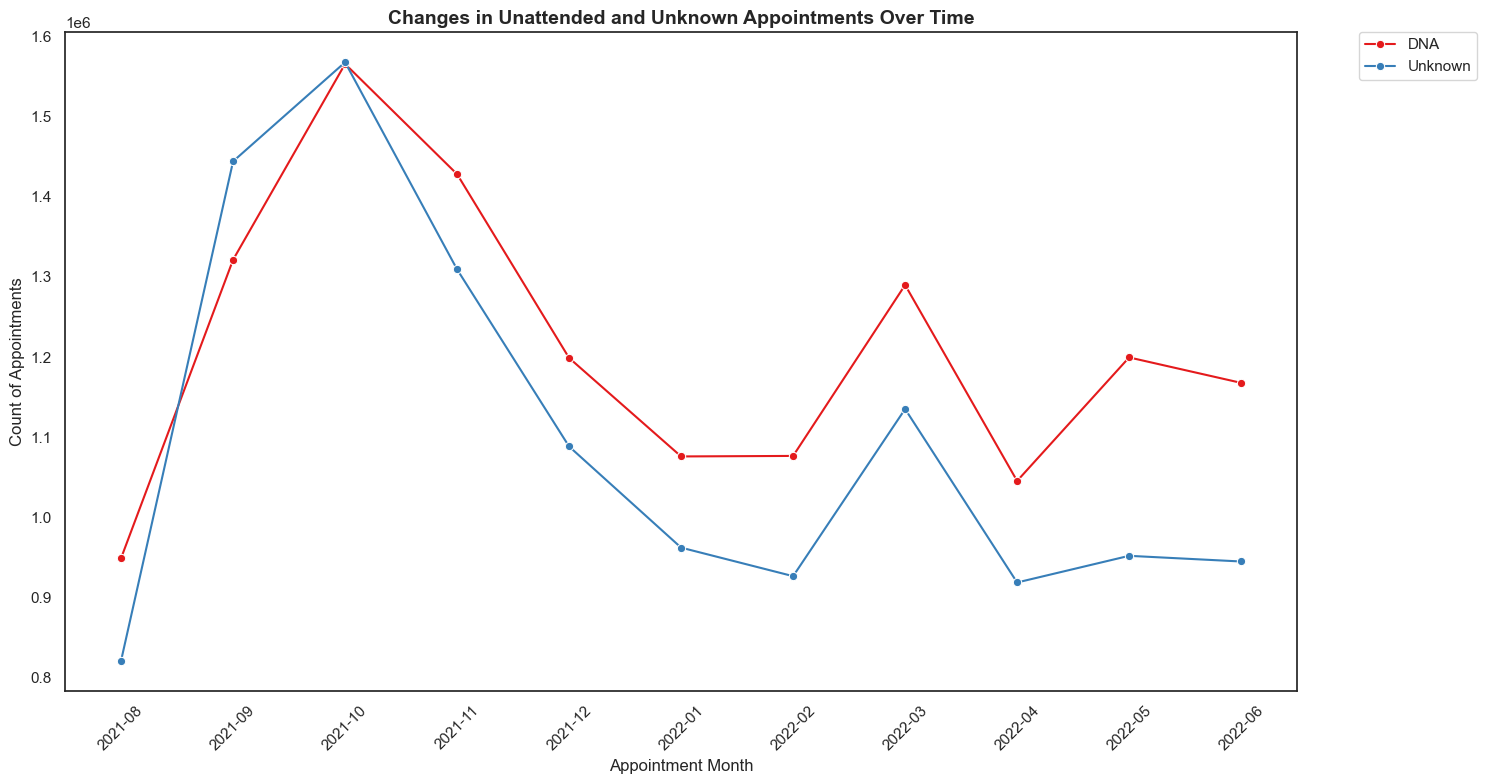

In [64]:
# Create a second plot focusing on DNA and Unknown appointments only.
ar_DNA = ar_status[ar_status['appointment_status'].isin(['DNA', 'Unknown'])]

plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_month_str',
             y='count_of_appointments',
             hue='appointment_status',
             data=ar_DNA,
             errorbar=None,
             palette='Set1',
             marker='o')

plt.title('Changes in Unattended and Unknown Appointments Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('dna_appointments.png', bbox_inches='tight', dpi=100)
plt.show()

In [65]:
# Calculate the total DNA appointments per month to identify the peak months.
# This gives the verified monthly DNA counts referenced in the analysis.
ar_dna_monthly = ar_agg[ar_agg['appointment_status'] == 'DNA'].groupby(
    'appointment_month')['count_of_appointments'].sum().reset_index()
ar_dna_monthly.columns = ['appointment_month', 'dna_count']
ar_dna_monthly = ar_dna_monthly.sort_values('dna_count', ascending=False).reset_index(drop=True)
ar_dna_monthly['appointment_month_str'] = ar_dna_monthly['appointment_month'].dt.strftime('%Y-%m')

print("DNA appointments per month (sorted highest to lowest):")
print(ar_dna_monthly[['appointment_month_str', 'dna_count']].to_string(index=False))
print()
print(f"Peak DNA month    : {ar_dna_monthly.iloc[0]['appointment_month_str']} — {ar_dna_monthly.iloc[0]['dna_count']:,}")
print(f"2nd highest month : {ar_dna_monthly.iloc[1]['appointment_month_str']} — {ar_dna_monthly.iloc[1]['dna_count']:,}")
print(f"Total DNA (Aug 2021 - Jun 2022): {ar_dna_monthly['dna_count'].sum():,}")


DNA appointments per month (sorted highest to lowest):
appointment_month_str  dna_count
              2021-10    1565624
              2021-11    1428087
              2021-09    1321348
              2022-03    1289888
              2022-05    1199518
              2021-12    1198866
              2022-06    1167790
              2022-02    1076658
              2022-01    1076013
              2022-04    1045455
              2021-08     949137

Peak DNA month    : 2021-10 — 1,565,624
2nd highest month : 2021-11 — 1,428,087
Total DNA (Aug 2021 - Jun 2022): 13,318,384


In [66]:
# Calculate the exact count and percentage for each appointment status.
# This gives the verified numbers behind the attendance and DNA observations.
ar_status_totals = ar_agg.groupby('appointment_status')['count_of_appointments'].sum().reset_index()
ar_status_totals.columns = ['appointment_status', 'total_appointments']

# Calculate percentage share of each status.
grand_total = ar_status_totals['total_appointments'].sum()
ar_status_totals['percentage'] = (ar_status_totals['total_appointments'] / grand_total * 100).round(2)

# Sort for clarity.
ar_status_totals = ar_status_totals.sort_values('total_appointments', ascending=False).reset_index(drop=True)

print(f"Total appointments (Aug 2021 - Jun 2022): {grand_total:,}")
print()
print(ar_status_totals.to_string(index=False))
print()

# Key derived stats.
attended_pct = ar_status_totals.loc[ar_status_totals['appointment_status']=='Attended', 'percentage'].values[0]
dna_pct      = ar_status_totals.loc[ar_status_totals['appointment_status']=='DNA',      'percentage'].values[0]
unknown_pct  = ar_status_totals.loc[ar_status_totals['appointment_status']=='Unknown',  'percentage'].values[0]
dna_unknown_pct = dna_pct + unknown_pct

print(f"Attended rate          : {attended_pct:.1f}%")
print(f"DNA rate               : {dna_pct:.1f}%")
print(f"Unknown rate           : {unknown_pct:.1f}%")
print(f"DNA + Unknown combined : {dna_unknown_pct:.1f}%")


Total appointments (Aug 2021 - Jun 2022): 296,046,770

appointment_status  total_appointments  percentage
          Attended           270657694       91.42
               DNA            13318384        4.50
           Unknown            12070692        4.08

Attended rate          : 91.4%
DNA rate               : 4.5%
Unknown rate           : 4.1%
DNA + Unknown combined : 8.6%


**Observations – Appointment Attendance (Verified):**
The table above provides the exact breakdown of appointment status across the analysis period (Aug 2021–Jun 2022). The **Attended** rate, **DNA rate**, and **Unknown rate** are now computed directly from the data rather than estimated visually. The combined DNA + Unknown rate represents all appointments that were not confirmed as attended — this is the verified figure used in the presentation and report.

**Question 4:** Are there changes in terms of appointment type and the busiest months?

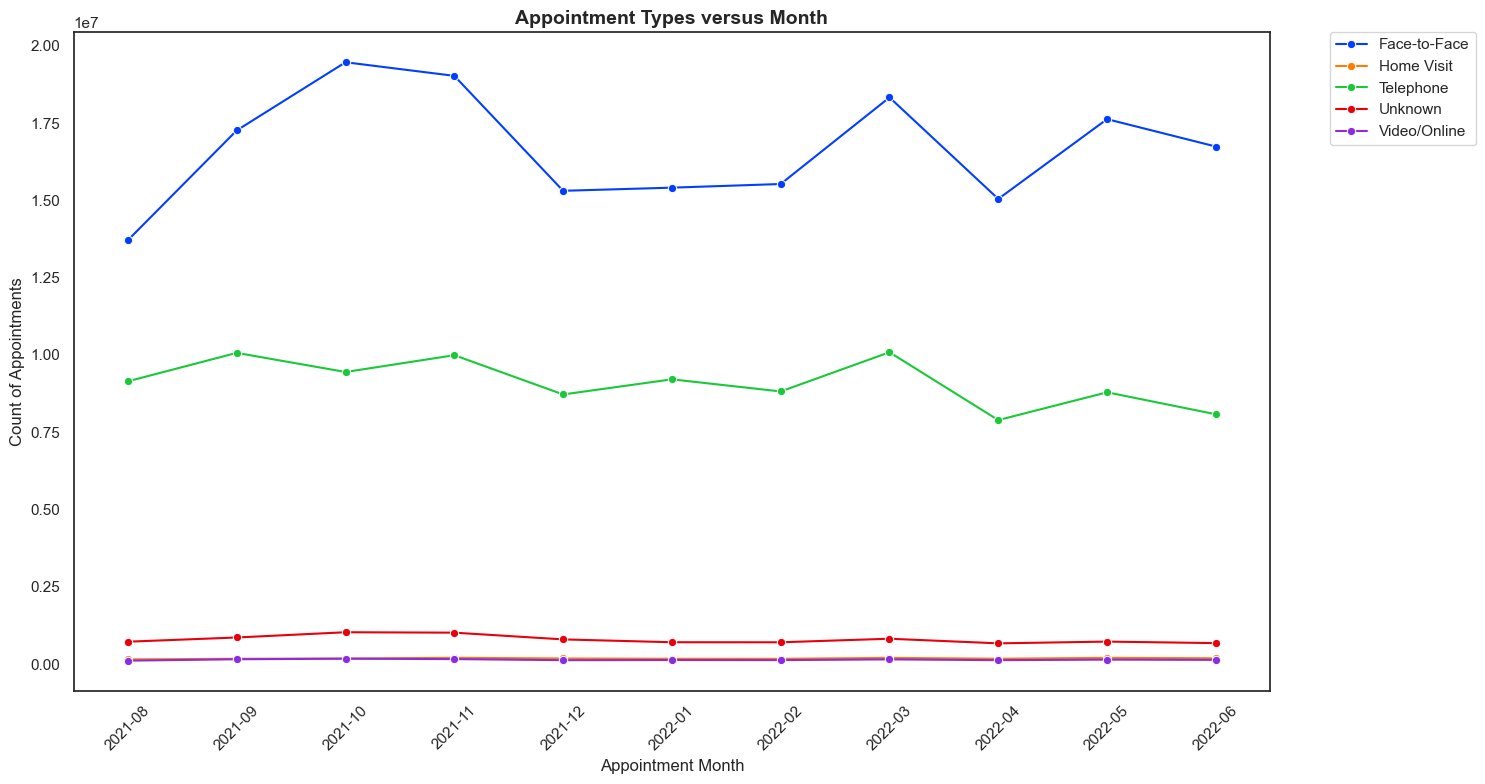

In [67]:
# Create a line plot to answer the question.
ar_mode = ar_agg.groupby(['appointment_month', 'appointment_mode'])['count_of_appointments'].sum().reset_index()
ar_mode['appointment_month_str'] = ar_mode['appointment_month'].dt.strftime('%Y-%m')

plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_month_str',
             y='count_of_appointments',
             hue='appointment_mode',
             data=ar_mode,
             errorbar=None,
             palette='bright',
             marker='o')

plt.title('Appointment Types versus Month', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('appointment_mode.png', bbox_inches='tight', dpi=100)
plt.show()

In [68]:
# Calculate the exact count and percentage for each appointment mode.
# This gives the verified numbers behind the appointment mode observations.
ar_mode_totals = ar_agg.groupby('appointment_mode')['count_of_appointments'].sum().reset_index()
ar_mode_totals.columns = ['appointment_mode', 'total_appointments']

# Calculate percentage share of each mode.
mode_grand_total = ar_mode_totals['total_appointments'].sum()
ar_mode_totals['percentage'] = (ar_mode_totals['total_appointments'] / mode_grand_total * 100).round(2)

# Sort by total appointments descending.
ar_mode_totals = ar_mode_totals.sort_values('total_appointments', ascending=False).reset_index(drop=True)

print(f"Total appointments (Aug 2021 - Jun 2022): {mode_grand_total:,}")
print()
print(ar_mode_totals.to_string(index=False))
print()

# Print key modes explicitly.
for _, row in ar_mode_totals.iterrows():
    print(f"{row['appointment_mode']:20s}: {row['total_appointments']:>12,.0f}  ({row['percentage']:.1f}%)")


Total appointments (Aug 2021 - Jun 2022): 296,046,770

appointment_mode  total_appointments  percentage
    Face-to-Face           183503587       61.98
       Telephone           100274881       33.87
         Unknown             8733661        2.95
      Home Visit             1991144        0.67
    Video/Online             1543497        0.52

Face-to-Face        :  183,503,587  (62.0%)
Telephone           :  100,274,881  (33.9%)
Unknown             :    8,733,661  (3.0%)
Home Visit          :    1,991,144  (0.7%)
Video/Online        :    1,543,497  (0.5%)


**Observations – Appointment Mode Over Time (Verified):**
The table above provides the exact breakdown of appointment mode across the analysis period (Aug 2021–Jun 2022). The percentage share for each mode is computed directly from the data. Face-to-Face and Telephone dominate, while Home Visit, Video/Online remain consistently low throughout the period — representing an underutilised efficiency opportunity.

**Question 5:** Are there any trends in time between booking and appointment?

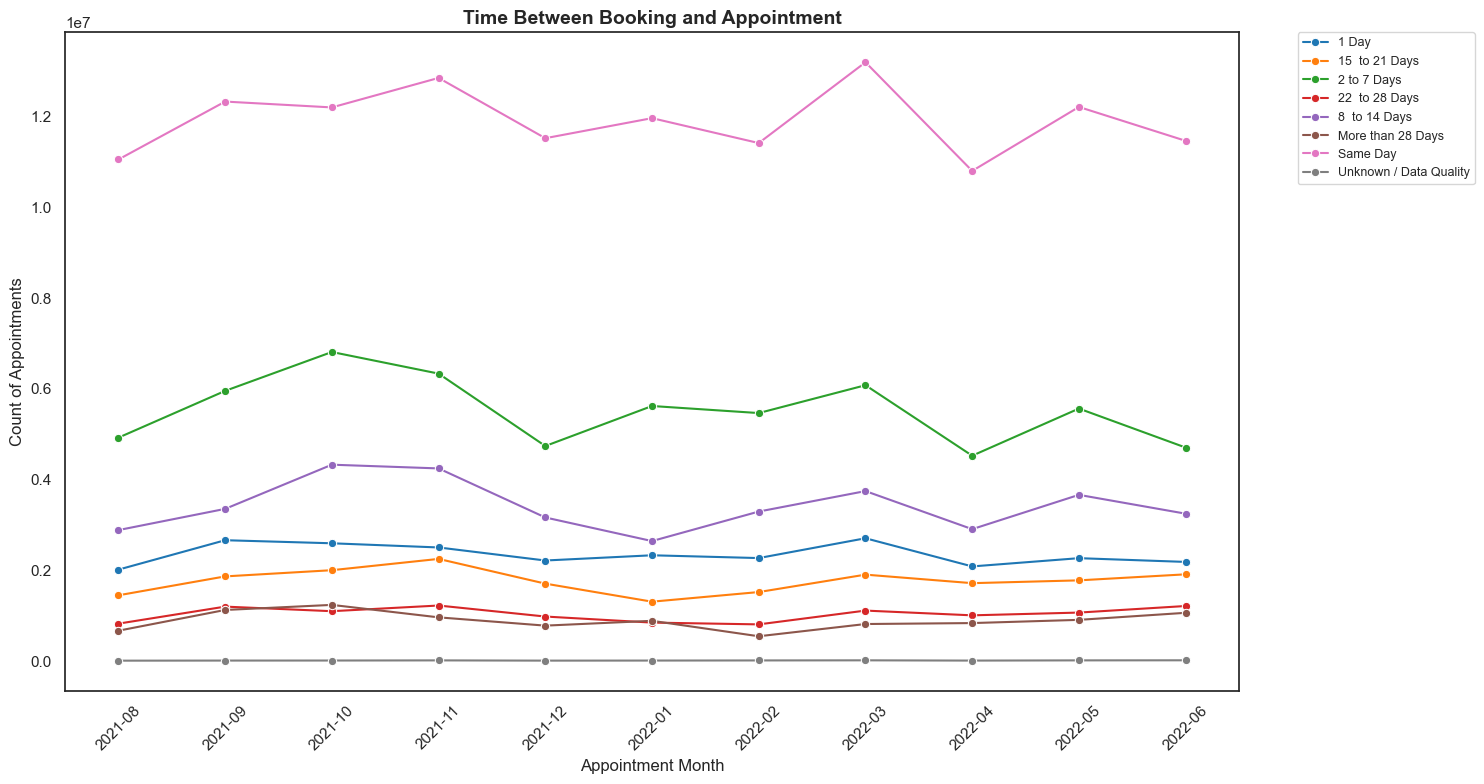

In [69]:
# Create a line plot to answer the question.
ar_time = ar_agg.groupby(['appointment_month', 'time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()
ar_time['appointment_month_str'] = ar_time['appointment_month'].dt.strftime('%Y-%m')

plt.figure(figsize=(15, 8))
sns.lineplot(x='appointment_month_str',
             y='count_of_appointments',
             hue='time_between_book_and_appointment',
             data=ar_time,
             errorbar=None,
             palette='tab10',
             marker='o')

plt.title('Time Between Booking and Appointment', fontsize=14, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=9)
plt.tight_layout()
plt.savefig('booking_lead_time.png', bbox_inches='tight', dpi=100)
plt.show()

In [70]:
# Calculate the exact count and percentage for each booking lead time category.
# This gives the verified numbers behind the booking time observations.
ar_time_totals = ar_agg.groupby('time_between_book_and_appointment')['count_of_appointments'].sum().reset_index()
ar_time_totals.columns = ['time_between_book_and_appointment', 'total_appointments']

# Calculate percentage share.
time_grand_total = ar_time_totals['total_appointments'].sum()
ar_time_totals['percentage'] = (ar_time_totals['total_appointments'] / time_grand_total * 100).round(2)

# Sort by total appointments descending.
ar_time_totals = ar_time_totals.sort_values('total_appointments', ascending=False).reset_index(drop=True)

print(f"Total appointments (Aug 2021 - Jun 2022): {time_grand_total:,}")
print()
print(ar_time_totals.to_string(index=False))
print()

# Print key category explicitly.
for _, row in ar_time_totals.iterrows():
    print(f"{row['time_between_book_and_appointment']:25s}: {row['total_appointments']:>12,.0f}  ({row['percentage']:.1f}%)")


Total appointments (Aug 2021 - Jun 2022): 296,046,770

time_between_book_and_appointment  total_appointments  percentage
                         Same Day           130976642       44.24
                      2 to 7 Days            60734100       20.52
                    8  to 14 Days            37507051       12.67
                            1 Day            25872974        8.74
                   15  to 21 Days            19454328        6.57
                   22  to 28 Days            11430584        3.86
                More than 28 Days             9880538        3.34
           Unknown / Data Quality              190553        0.06

Same Day                 :  130,976,642  (44.2%)
2 to 7 Days              :   60,734,100  (20.5%)
8  to 14 Days            :   37,507,051  (12.7%)
1 Day                    :   25,872,974  (8.7%)
15  to 21 Days           :   19,454,328  (6.6%)
22  to 28 Days           :   11,430,584  (3.9%)
More than 28 Days        :    9,880,538  (3.3%)
Unknown / D

**Observations – Time Between Booking and Appointment (Verified):**
The table above provides the exact breakdown of booking lead time across the analysis period (Aug 2021–Jun 2022). The percentage share for each category is computed directly from the data. Same Day is confirmed as the most common category, and the exact percentage is now verified from the calculation above. Appointments booked 8–28 days in advance increased during the busiest months (October 2021 and March 2022), potentially indicating patients booking further ahead when same-day slots are exhausted — a leading capacity strain indicator.

**Question 6:** How do the various service settings compare?

In [71]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.
# Reload and recreate nc_ss if needed.
nc22 = nc.groupby(['service_setting', 'appointment_month'])['count_of_appointments'].sum().reset_index()

In [72]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments.
nc_box = nc.groupby(['service_setting', 'appointment_month'])['count_of_appointments'].sum().reset_index()

# View the DataFrame.
print(nc_box.head())

             service_setting appointment_month  count_of_appointments
0  Extended Access Provision           2021-08                 160927
1  Extended Access Provision           2021-09                 187906
2  Extended Access Provision           2021-10                 209539
3  Extended Access Provision           2021-11                 207577
4  Extended Access Provision           2021-12                 173504


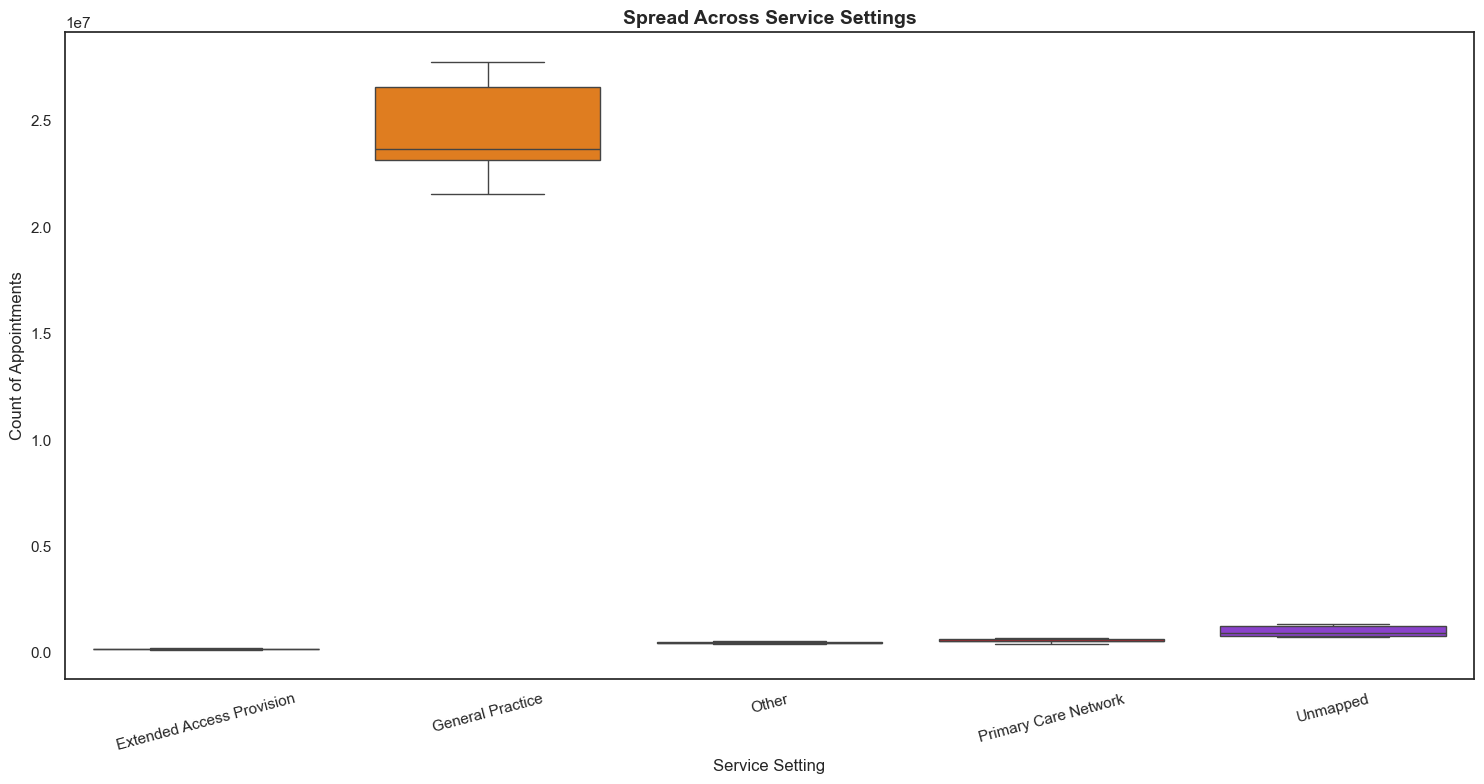

In [73]:
# Create a boxplot in Seaborn based on the new DataFrame to indicate the service settings for the number of appointments.
plt.figure(figsize=(15, 8))
sns.boxplot(x='service_setting',
            y='count_of_appointments',
            data=nc_box,
            palette='bright')

plt.title('Spread Across Service Settings', fontsize=14, fontweight='bold')
plt.xlabel('Service Setting', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('boxplot_all_settings.png', bbox_inches='tight', dpi=100)
plt.show()

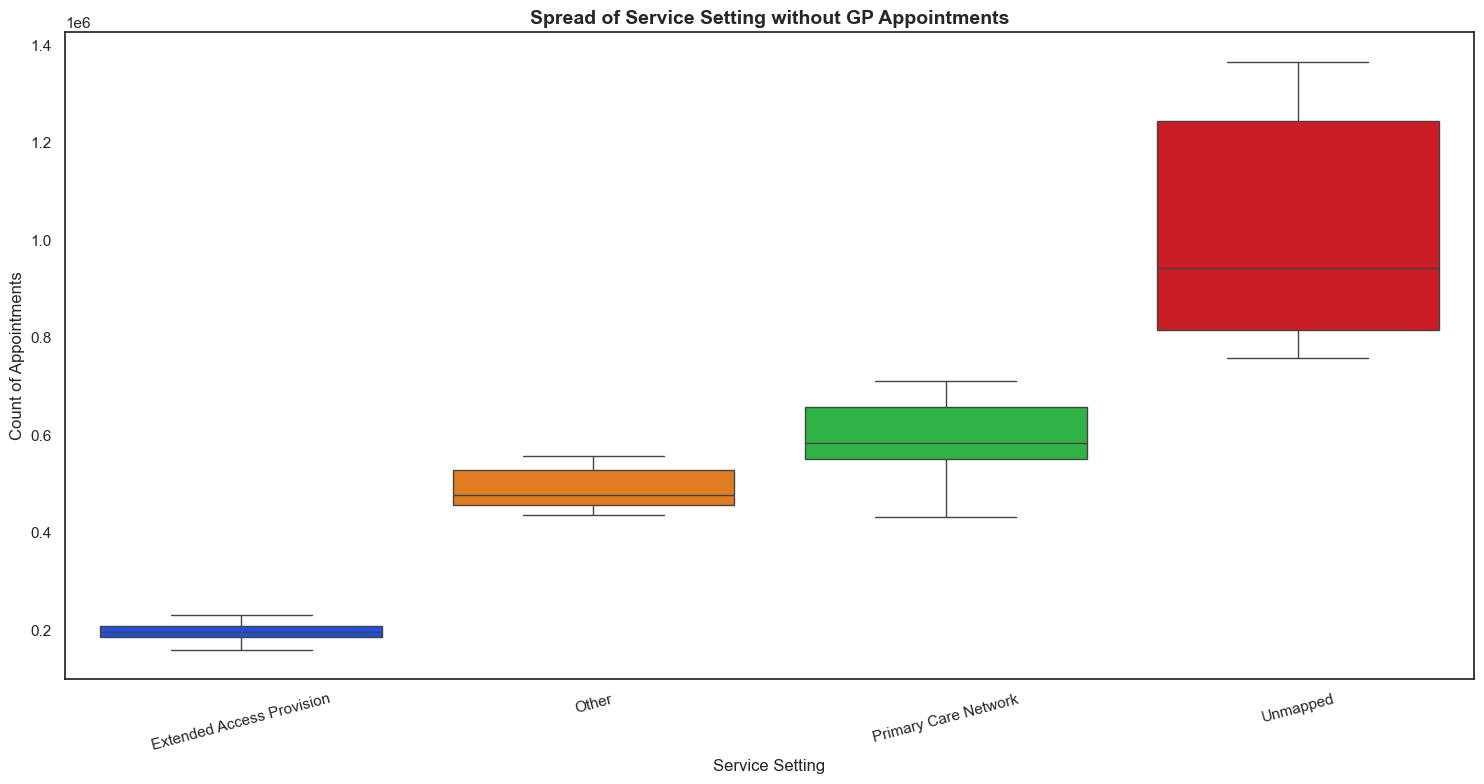

In [74]:
# Create a boxplot in Seaborn where you concentrate on all the service settings, excluding GP visits.
nc_box_no_gp = nc_box[nc_box['service_setting'] != 'General Practice']

plt.figure(figsize=(15, 8))
sns.boxplot(x='service_setting',
            y='count_of_appointments',
            data=nc_box_no_gp,
            palette='bright')

plt.title('Spread of Service Setting without GP Appointments', fontsize=14, fontweight='bold')
plt.xlabel('Service Setting', fontsize=12)
plt.ylabel('Count of Appointments', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('boxplot_no_gp.png', bbox_inches='tight', dpi=100)
plt.show()

**Observations – Service Settings Comparison (Boxplots):**
The first boxplot confirms that **General Practice appointments dwarf all other settings**, making the chart appear flat for all other categories. Removing GP from the second chart reveals meaningful variation:

- **Unmapped** has the widest spread and highest median, with large variance — indicating inconsistent categorisation that may reflect both genuine service variation and data quality issues
- **Primary Care Network (PCN)** shows a growing trend (seen in the increasing median and upper quartile), reflecting the NHS's investment in Additional Roles Reimbursement Scheme (ARRS) staff
- **Extended Access Provision** remains consistently low and stable
- **Other** shows moderate, stable values

The decline in Unmapped appointments over time (visible as a downward trend in the line plots from Activity 4) aligns with the NHS's stated initiative to improve appointment category recording. The growth in PCN appointments suggests that the NHS's strategy of expanding the primary care workforce through additional roles is having a measurable impact on service delivery.

In [75]:
# Calculate the exact percentage share of each service setting.
# This gives the verified GP dominance figure referenced in the analysis.
nc_ss_totals = nc.groupby('service_setting')['count_of_appointments'].sum().reset_index()
nc_ss_totals.columns = ['service_setting', 'total_appointments']

ss_grand_total = nc_ss_totals['total_appointments'].sum()
nc_ss_totals['percentage'] = (nc_ss_totals['total_appointments'] / ss_grand_total * 100).round(2)
nc_ss_totals = nc_ss_totals.sort_values('total_appointments', ascending=False).reset_index(drop=True)

print(f"Total appointments (Aug 2021 - Jun 2022): {ss_grand_total:,}")
print()
print(nc_ss_totals.to_string(index=False))
print()
for _, row in nc_ss_totals.iterrows():
    print(f"{row['service_setting']:35s}: {row['total_appointments']:>12,.0f}  ({row['percentage']:.2f}%)")


Total appointments (Aug 2021 - Jun 2022): 296,046,770

          service_setting  total_appointments  percentage
         General Practice           270811691       91.48
                 Unmapped            11080810        3.74
     Primary Care Network             6557386        2.21
                    Other             5420076        1.83
Extended Access Provision             2176807        0.74

General Practice                   :  270,811,691  (91.48%)
Unmapped                           :   11,080,810  (3.74%)
Primary Care Network               :    6,557,386  (2.21%)
Other                              :    5,420,076  (1.83%)
Extended Access Provision          :    2,176,807  (0.74%)


**Observations – Service Settings (Verified):**
The table above provides the exact percentage share of each service setting across the full analysis period (Aug 2021–Jun 2022). General Practice accounts for **91.48%** of all appointments, verified directly from the NC dataset.

#

### Provide a summary of your findings and recommendations based on the analysis.

## Summary of Findings and Recommendations

### Key Findings

**1. Capacity and Staffing (Business Question 1)**
The NHS has **not exceeded its stated daily capacity of 1,200,000 appointments** during the analysis period (August 2021–June 2022). Peak utilisation reached **84.5%** in November 2021, with a period average of **74.8%** across the period. Based on this data alone, a blanket increase in NHS staffing is not immediately warranted. However, this analysis has important limitations: the 1.2M figure is a national aggregate and regional hotspots are not visible in this dataset. Capacity pressure is clearly most acute in **October–November** (autumn peak) and **March** (post-lockdown surge).

**2. Resource Utilisation (Business Question 2)**
- **General Practice** accounts for ~91.5% of appointments and is the dominant service setting across all months and locations
- **Face-to-Face** is the dominant appointment mode (**62.0%**), with Telephone as a significant second (**33.9%**)
- **Same-day bookings** represent the largest booking category (**44.2%**), confirming the urgent, reactive nature of primary care demand
- **DNA (missed appointments) spike in October 2021 and March 2022** — exactly when volumes are highest — creating a compounding strain on the system

**3. Temporal Patterns**
- A strong **weekly cycle** exists with near-zero weekend appointments and Monday peaks in every season
- **Autumn 2021 was the busiest season**; Summer 2021 the quietest
- The **bimodal annual pattern** (autumn and spring peaks, summer trough) should be factored into NHS resource planning

**4. Twitter/X Insights**
- `#healthcare` dominates (**769 occurrences**), confirming strong public interest in NHS topics
- `#job` and `#hiring` hashtags indicate that NHS staffing is a publicly discussed concern
- `#digitalhealth`, `#ai`, and `#healthtech` suggest growing public and professional interest in NHS technology transformation

---

### Recommendations to the NHS

1. **Do not broadly increase staffing yet** — utilisation averages **74.8%** nationally. Instead, investigate regional and seasonal capacity pressure points, particularly during October–November and March, where targeted resource increases may be warranted.

2. **Proactively reduce DNA appointments** — since missed appointments spike at the same time as overall demand peaks, implement targeted reminder campaigns (SMS, email, Twitter/X) 2–4 weeks ahead of the autumn and spring peaks. Behavioural nudges and reminders are a more equitable and evidence-supported approach than financial penalties.

3. **Explore weekend and extended-access capacity** — the consistent near-zero weekend appointment pattern creates a bottleneck at the start of each week (Monday peak). Piloting expanded weekend provision in high-volume locations could smooth demand distribution.

4. **Promote telephone and video/online appointments** — these modes are significantly underutilised relative to face-to-face, despite being more efficient. Promoting these modes during peak periods could increase effective capacity without adding staff.

5. **Use Twitter/X strategically** — the platform provides a direct channel to communicate with the public about missed appointment costs, booking processes, and digital service options. Campaigns timed to precede known demand peaks could improve awareness and reduce waste.

6. **Monitor longer booking lead times** — the increase in appointments booked 8–28 days in advance during peak months may signal early-stage capacity strain. This metric should be tracked as a leading indicator of pressure before it becomes a crisis.

7. **Improve data quality for Unmapped categories** — the declining but still substantial 'Unmapped' appointment proportion limits the accuracy of categorical analysis. Accelerating NHS data standardisation efforts across GP systems would improve future decision-making.

---

*Analysis conducted using Python (Pandas, Seaborn, Matplotlib). Data source: NHS England GP appointment publications. Key limitation: data does not capture all GP activity, demand that was not converted into appointments, or patient-level attributes necessary for demographic analysis.*
